In [1]:
import torch
import pickle
import pandas as pd
import numpy as np
import sys
import glob
import math
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

from src.utils import (
    get_valid_dir,
    set_seed,
    get_linear_predictions,
    get_knn_predictions,
    get_embs,
    is_subset,
    process_data_loader,
    print_metrics_in_latex,
    calculate_metrics,
    get_checkpoint_paths,
    mergekfold_results,
    save_normalized_conf_matrices,
    plot_pred_vs_true,
    get_class_dependent_predictions,
    generate_radar_plots,
    filter_classes,
    get_mlp_predictions,
)

from src.models_multimodal import (
    load_model,
)

from sklearn.metrics import roc_curve, auc

from src.dataloader import (
    load_data,
    NoisyDataLoader,
)

In [2]:
def read_in_maven_predictions(model_label, mlp_weight, datadir):
    """
    Reads dataframe of predictions generated on single objects 
    along with metadata table of the dataset.

    Returns dataframe of the predictions per-object.
    """
    #read in individual object predictions from evaluate_models_single output
    preds_df = pd.read_csv(f'./{model_label}+MLP+two_w{mlp_weight}_single_objs.csv')

    #read in dataset dsecription
    dataset = pd.read_csv(f'./data/test/{datadir}/ZTFBTS_TransientTable.csv')

    # creating placeholder column for the k-fold for which the obj belongs to the validation set for
    preds_df['kfold_for_val'] = [0]*len(preds_df)

    pd.set_option('display.max_rows',200)
    preds_df

    #loading in models and validation sets
    directories = [
        f"models/{model_label}",
    ]  
    names = [
        f"{model_label}",
    ]
    models = []

    paths = []
    ids = []
    labels = []
    # Finding all checkpoints
    for id, (directory, label) in enumerate(zip(directories, names)):
        paths_to_checkpoint, name, id = get_checkpoint_paths(directory, label, id)
        paths.extend(paths_to_checkpoint)
        ids.extend(id)
        labels.extend(name)

    for i, path in enumerate(paths):
        print(f"loading {labels[i]}")
        # print(path)
        models.append(load_model(path))

    # if obj appears in list of val_filenames from model, then update k-fold_in_valid to the model i we are on
    for i in range(len(models)):
        val_filenames = models[i][-1]
        preds_df.loc[preds_df['SN'].isin(val_filenames), 'kfold_for_val'] = i

    #cross-matching objects between DFs to add SN type to preds_df
    types = []
    for i,sn in enumerate(preds_df['SN'][::3]):
        sn_ztf = sn[:12]
        snt = dataset.loc[dataset.ZTFID==sn_ztf, 'type'].iloc[0]
        types.append([snt]*3)

    preds_df['type'] = np.array(types).flatten()

    preds_df.loc[preds_df['type']=='SN Ib/c', 'type'] = 'SN Ibc'

    return preds_df, models, labels, ids

In [3]:
class_names = {
    0: ("single-peaked", "blue"),
    1: ("double-peaked", "green"),
}

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

In [4]:
def plot_lc_only_cm_avg(df, savepath):
    # Calculate the confusion matrix and normalize it
    cm = confusion_matrix(df["true_label"], df["prediction"])
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # Create the plot
    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(
        cm_normalized,
        annot=True,
        annot_kws={"size": 45},
        fmt=".2f",
        cmap="Purples",
        xticklabels=[class_names[label][0] for label in sorted(class_names)],
        yticklabels=[class_names[label][0] for label in sorted(class_names)],
        vmin=0,
        vmax=1,
        cbar=False,
        # cbar_kws={"pad": 0.01},
    )
    ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

    plt.title('Light curves', fontsize=34, pad=15)
    plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
    plt.ylabel("True Label", fontsize=34 ,labelpad=15)

    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return

In [5]:
def plot_lc_only_cm_avg_precision(df, savepath):
    # Calculate the confusion matrix and normalize it
    cm = confusion_matrix(df["true_label"], df["prediction"])

    # Normalize by column sums (precision)
    cm_normalized_precision = cm.astype("float") / cm.sum(axis=0)[np.newaxis, :]

    # Create the plot
    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(
        cm_normalized_precision,
        annot=True,
        annot_kws={"size": 45},
        fmt=".2f",
        cmap="Purples",
        xticklabels=[class_names[label][0] for label in sorted(class_names)],
        yticklabels=[class_names[label][0] for label in sorted(class_names)],
        vmin=0,
        vmax=1,
        cbar=False,
        # cbar_kws={"pad": 0.01},
    )
    ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

    plt.title('Light curves', fontsize=34, pad=15)
    plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
    plt.ylabel("True Label", fontsize=34 ,labelpad=15)

    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return

In [6]:
def plot_lc_only_per_fold(df_full, modality, i, fold, savepath, display_ratio=False):
    # for i,fold in enumerate(folds_list):
    df = df_full.loc[modality&fold]

    # Calculate the confusion matrix and normalize it
    cm = confusion_matrix(df["true_label"], df["prediction"])
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # Create the plot
    plt.figure(figsize=(8, 8))
    if i==0:
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=[class_names[label][0] for label in sorted(class_names)],
            yticklabels=[class_names[label][0] for label in sorted(class_names)],
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )
    else:
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=[class_names[label][0] for label in sorted(class_names)],
            yticklabels=False,
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )

    ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

    plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
    if i==0:
        plt.ylabel("True Label", fontsize=34 ,labelpad=15)

    if display_ratio:
        num_dp = len(df.loc[df['true_label']==1])
        total = len(df)
        plt.title(f'{num_dp}:{total}', fontsize=34)
    
    #per-fold
    plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return

In [7]:
def calc_roc_auc(models, labels, ids, datadir, model_label):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    data_dir = f'data/test/{datadir}'
    spectra_dir = f'data/test/{datadir}_spectra'

    kval=0
    for output, label, id in zip(models, labels, ids):
        (
            model,
            combinations,
            regression,
            classification,
            n_classes,
            cfg,
            cfg_extra_args,
            train_filenames,
            val_filenames,
        ) = output

        set_seed(cfg["seed"])

        print('n_classes', n_classes)

        # Spectral data is cut to this length
        dataset_train, nband, filenames_read, _ = load_data(
            data_dir,
            spectra_dir,
            max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
            combinations=cfg_extra_args["combinations"],
            spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
            filenames=train_filenames,
            n_classes=n_classes,
            handpicked_folds=cfg_extra_args["handpicked_folds"],
            handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
        )

        # Check that the filenames read are a subset of the training filenames from the already trained models
        assert is_subset(filenames_read, train_filenames)

        dataset_val, nband, filenames_read, _ = load_data(
            data_dir,
            spectra_dir,
            max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
            combinations=cfg_extra_args["combinations"],
            spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
            filenames=val_filenames,
            n_classes=n_classes,
            handpicked_folds=cfg_extra_args["handpicked_folds"],
            handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
        )
        
        # Check that the filenames read are a subset of the training filenames from the already trained models
        assert is_subset(filenames_read, val_filenames)

        train_loader_no_aug = NoisyDataLoader(
            dataset_train,
            batch_size=cfg["batchsize"],
            noise_level_img=0,
            noise_level_mag=0,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
            combinations=cfg_extra_args["combinations"],
        )

        val_loader_no_aug = NoisyDataLoader(
            dataset_val,
            batch_size=cfg["batchsize"],
            noise_level_img=0,
            noise_level_mag=0,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
            combinations=cfg_extra_args["combinations"],
        )

        model = model.to(device)
        model.eval()
        
        #y_pred empty if regression is not True
        y_true, y_true_label, y_pred, lc_data = process_data_loader(
            val_loader_no_aug,
            regression,
            classification,
            device,
            model,
            combinations=cfg_extra_args["combinations"],
        )
        y_true_train, y_true_train_label, _, _ = process_data_loader(
            train_loader_no_aug,
            regression,
            classification,
            device,
            model,
            combinations=cfg_extra_args["combinations"],
        )

        print("===============================")
        print(f"Model: {label}")
        print(f"Using data modalities: {cfg_extra_args['combinations']}")
        
        embs_list, combs = get_embs(
                model, val_loader_no_aug, cfg_extra_args["combinations"], ret_combs=True
            )
        embs_list_train = get_embs(model, train_loader_no_aug, combinations)
        subclasses = torch.tensor(
            [0,1] 
        )
        embs_list, y_true_label, lc_data = filter_classes(
            embs_list, y_true_label, lc_data, subclasses
        )
        embs_list_train, y_true_train_label, _ = filter_classes(
            embs_list_train, y_true_train_label, None, subclasses
        )

        X_val, Y_val = embs_list[0], y_true_label,

        # Ensure Y is 2D (necessary for sklearn)
        if (Y_val is not None) and (len(Y_val.shape) == 1):
            Y_val = Y_val[:, np.newaxis]

        #making ROC and AUC plots
        model = pickle.load(open(f'models/mlp-states/{model_label}+MLP+two_lightcurve_kfold{kval}_w1.0.pkl', 'rb'))
        # If validation data is provided, make predictions on that, otherwise on training data
        if X_val is not None and Y_val is not None:
            logits = model(X_val)
            probs = torch.sigmoid(logits)        # Apply sigmoid to get probabilities
            fpr, tpr, thresholds = roc_curve(Y_val.detach().numpy(), probs.detach().numpy())  # Calculate ROC
            # print(f'thresholds: {thresholds}')
            roc_auc = auc(fpr, tpr)                         # Calculate AUC
            predictions = (probs >= 0.5).float() # Convert probabilities to binary predictions (threshold = 0.5)
            # Plot the ROC curve
            plt.figure()  
            plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc, color='mediumslateblue')
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'{combs[0]}, kfold{kval}')
            plt.legend(loc='lower right')
            
            for i,t in enumerate(thresholds):
                plt.text(fpr[i], tpr[i], "%.3f"%t, ha="right")

            plt.savefig(f'figures/{model_label}_kfold{kval}_roc.png', dpi=300)
            plt.show()
        kval+=1
    return

In [8]:
# making loss function plots better
def plot_loss4paper(loss_path, save_path):
    loss = pd.read_csv(f'handpicked-kfold-results/augmented_dataset_results/{loss_path}',
                    skiprows=1, names=['epoch','loss','loss_val'])

    plt.figure()
    plt.plot(loss['epoch'], np.log10(loss['loss']), label='Training', color='#D48FB3', linewidth=4)
    plt.plot(loss['epoch'], np.log10(loss['loss_val']), label='Validation', color='#7A79CC', linewidth=4)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('log$_{10}$(loss)', fontsize=20, )

    plt.tick_params(left=True, bottom=True, axis='both', labelsize=17)

    plt.legend(frameon=False, fontsize=15)
    plt.tight_layout()
    plt.savefig(f'handpicked-kfold-results/augmented_dataset_results/{save_path}', dpi=300)

In [4]:
################################################################
#
#
# confusion matrices for the pre-augment highly imbalanced set
#
#
################################################################

In [376]:
# pre aug results
model_label =  'multipeak-finetune-cFrF-picked-kfolds'
mlp_weight = 5.0
datadir = 'all_v1'

preds_df_9010,_,_,_ = read_in_maven_predictions(model_label, mlp_weight, datadir)

loading multipeak-finetune-cFrF-picked-kfolds
loading multipeak-finetune-cFrF-picked-kfolds
loading multipeak-finetune-cFrF-picked-kfolds
loading multipeak-finetune-cFrF-picked-kfolds
loading multipeak-finetune-cFrF-picked-kfolds


In [ ]:
# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df_9010['true_label'] == 0)
dp = ~sp

correct = (preds_df_9010['true_label']==preds_df_9010['prediction'])
incorrect = ~correct

lc = (preds_df_9010['modality']=='lightcurve')
spec = (preds_df_9010['modality']=='spectral')
lcnspec = (preds_df_9010['modality']=='lightcurveandspectral')

kfold1 = (preds_df_9010['kfold_for_val']==0)
kfold2 = (preds_df_9010['kfold_for_val']==1)
kfold3 = (preds_df_9010['kfold_for_val']==2)
kfold4 = (preds_df_9010['kfold_for_val']==3)
kfold5 = (preds_df_9010['kfold_for_val']==4)

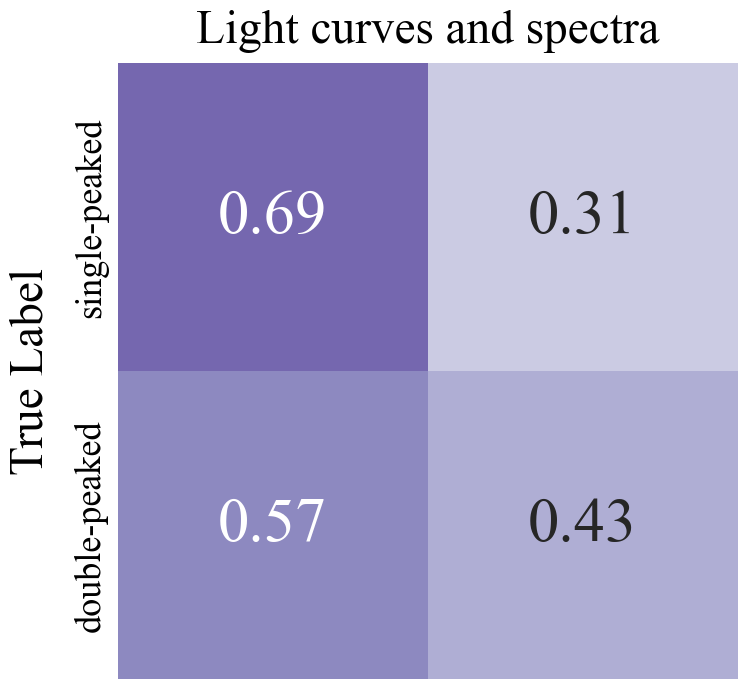

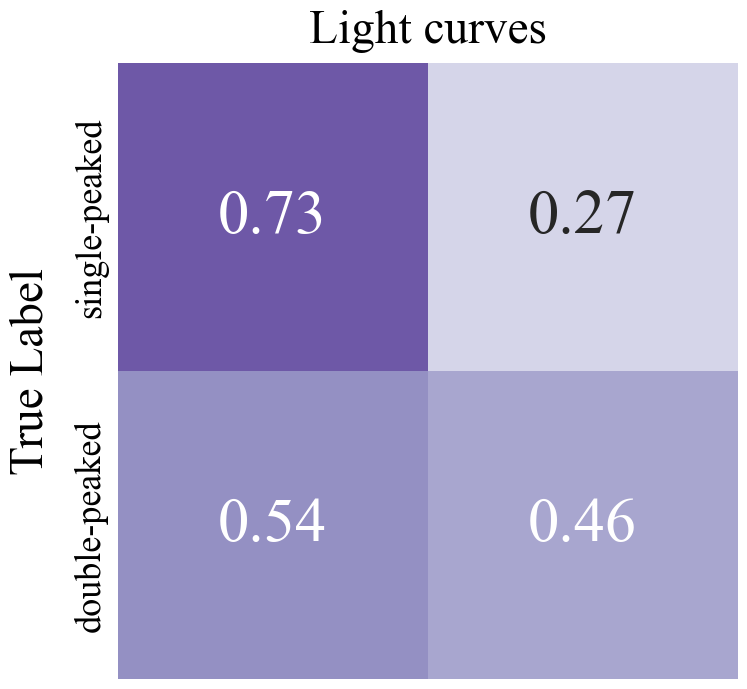

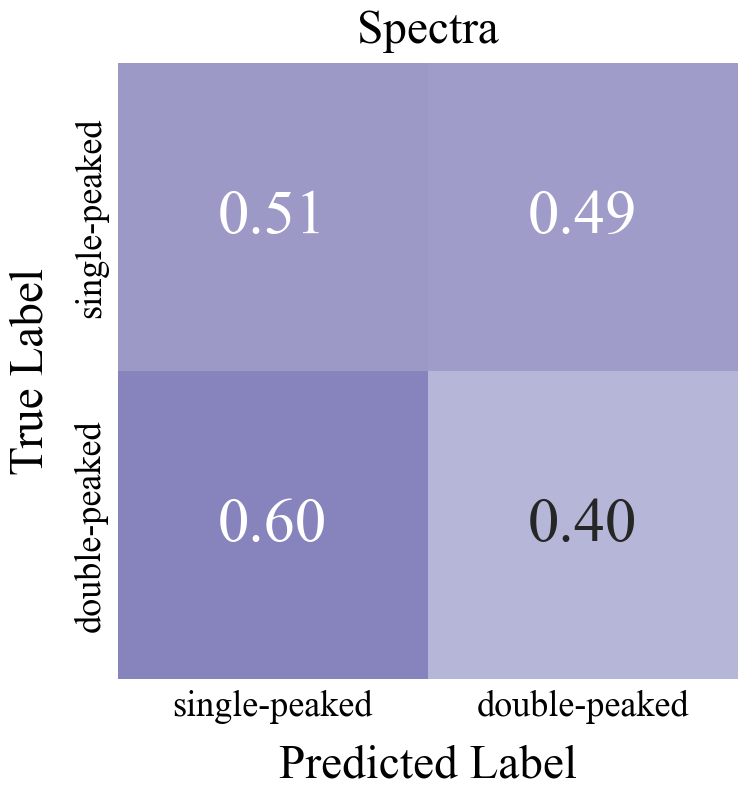

In [400]:
# making the CM
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

modalities = ['lightcurveandspectral', 'lightcurve', 'spectral']

for modality in modalities:
# modality = 'lightcurve'
    if modality=='lightcurveandspectral':
        df = preds_df_9010.loc[lcnspec] #can restrict to just one fold by adding: &kfoldX
    elif modality=='lightcurve':
        df = preds_df_9010.loc[lc]
    elif modality=='spectral':
        df = preds_df_9010.loc[spec]
    else:
        print('Modality not supported')
        continue

    # Calculate the confusion matrix and normalize it
    cm = confusion_matrix(df["true_label"], df["prediction"])
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # Create the plot
    plt.figure(figsize=(8, 8))
    if modality!='spectral':
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=False,
            yticklabels=[class_names[label][0] for label in sorted(class_names)],
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )
    else:
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=[class_names[label][0] for label in sorted(class_names)],
            yticklabels=[class_names[label][0] for label in sorted(class_names)],
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )
    ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

    if modality=='lightcurveandspectral':
        plt.title('Light curves and spectra', fontsize=34, pad=15)
    elif modality=='lightcurve':
        plt.title('Light curves', fontsize=34, pad=15)
    elif modality=='spectral':
        plt.title('Spectra', fontsize=34, pad=15)
        plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
    
    plt.ylabel("True Label", fontsize=34 ,labelpad=15)
    
    plt.savefig(f'handpicked-kfold-results/9010_dataset_results/{model_label}+MLP+two_{modality}_w{mlp_weight}_from_individ.png', 
                dpi=300, bbox_inches='tight')
    # #per-fold
    # plt.savefig(f'handpicked-kfold-results/augmented_dataset_results/3fold-results/randdrop-results/per-fold-results/{model_label}+MLP+two_{modality}_w{mlp_weight}_fold0_from_individ.png', 
    #             dpi=300, bbox_inches='tight')

    plt.show()

In [193]:
################################################################
#
#
#     confusion matrices for the augmented 60/40 dataset
#
#
################################################################

In [ ]:
# post-aug (i.e. w/ GP objs)
model_label =  'multipeak-finetune-cFrF-picked-kfolds-aug'
mlp_weight = 1.0
datadir = 'all'

preds_df_6040, models, labels, ids = read_in_maven_predictions(model_label, mlp_weight, datadir)

loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug


In [195]:
# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df_6040['true_label'] == 0)
dp = ~sp

correct = (preds_df_6040['true_label']==preds_df_6040['prediction'])
incorrect = ~correct

lc = (preds_df_6040['modality']=='lightcurve')
spec = (preds_df_6040['modality']=='spectral')
lcnspec = (preds_df_6040['modality']=='lightcurveandspectral')

kfold1 = (preds_df_6040['kfold_for_val']==0)
kfold2 = (preds_df_6040['kfold_for_val']==1)
kfold3 = (preds_df_6040['kfold_for_val']==2)
kfold4 = (preds_df_6040['kfold_for_val']==3)
kfold5 = (preds_df_6040['kfold_for_val']==4)

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 135/135 [00:00<00:00, 676.23it/s]


Loading spectra ...


100%|██████████| 135/135 [00:00<00:00, 2294.32it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 30/30 [00:00<00:00, 641.85it/s]


Loading spectra ...


100%|██████████| 30/30 [00:00<00:00, 1982.03it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']


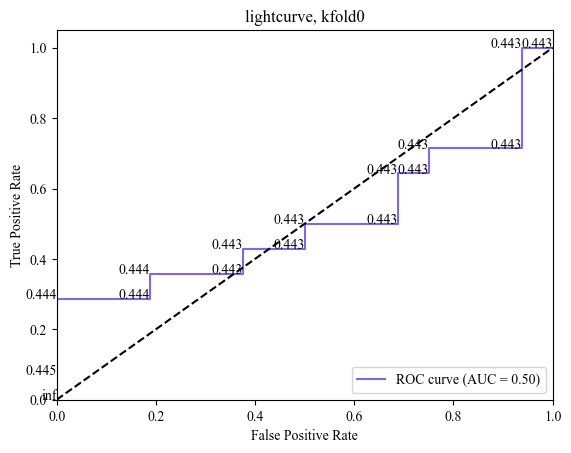

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 131/131 [00:00<00:00, 694.16it/s]


Loading spectra ...


100%|██████████| 131/131 [00:00<00:00, 2035.78it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 34/34 [00:00<00:00, 668.20it/s]


Loading spectra ...


100%|██████████| 34/34 [00:00<00:00, 2018.00it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']


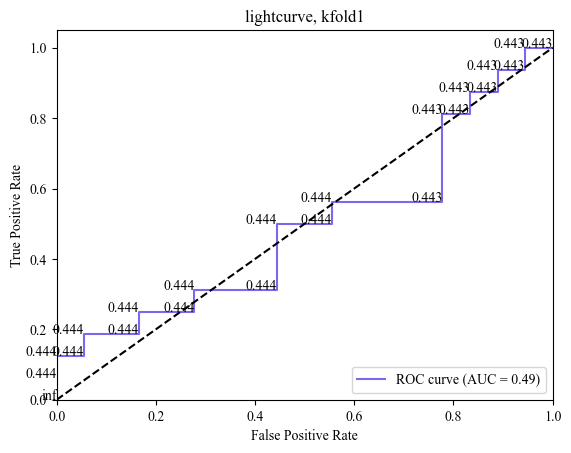

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 629.67it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2104.10it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 628.14it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 2094.80it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']


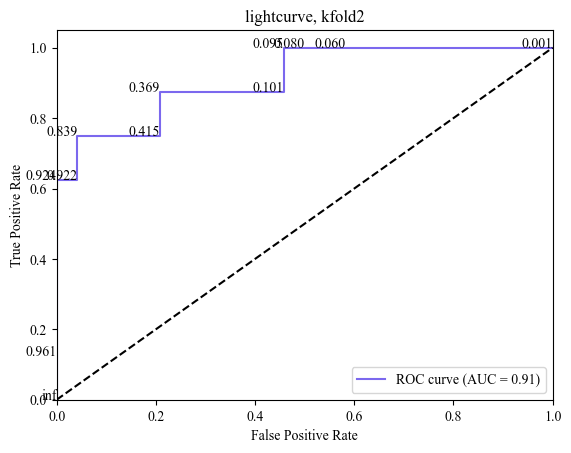

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 705.53it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2325.25it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 675.80it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 2236.63it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']


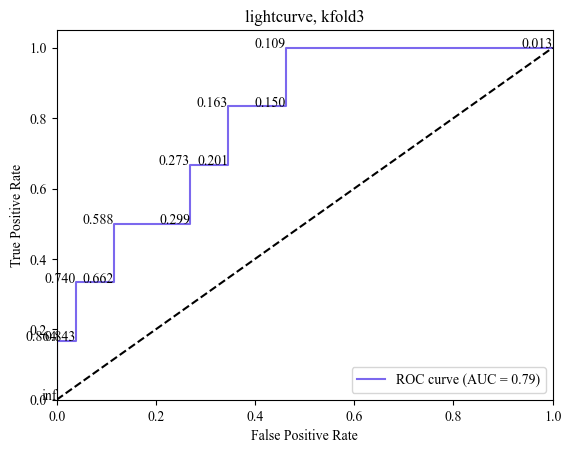

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 128/128 [00:00<00:00, 669.92it/s]


Loading spectra ...


100%|██████████| 128/128 [00:00<00:00, 2296.42it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 37/37 [00:00<00:00, 659.32it/s]


Loading spectra ...


100%|██████████| 37/37 [00:00<00:00, 1837.43it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']


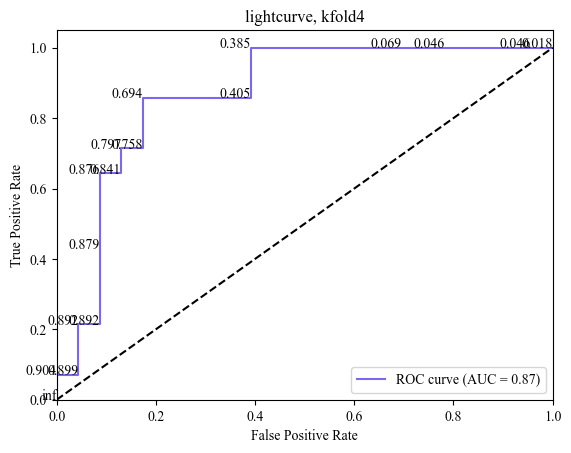

In [190]:
calc_roc_auc(models, labels, ids, datadir, model_label)

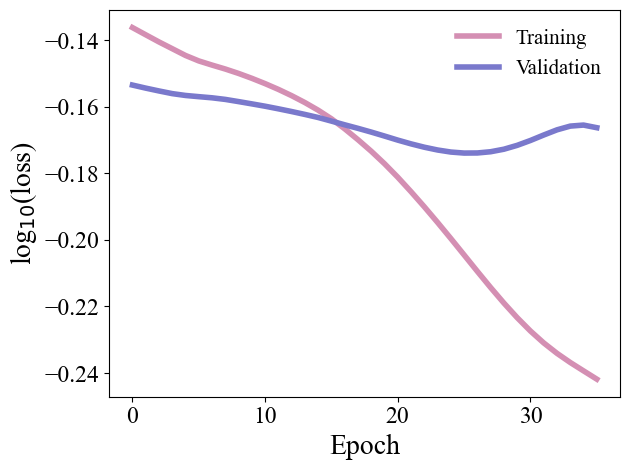

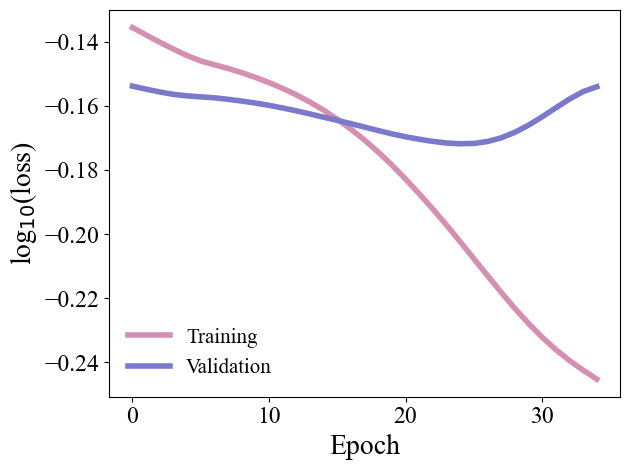

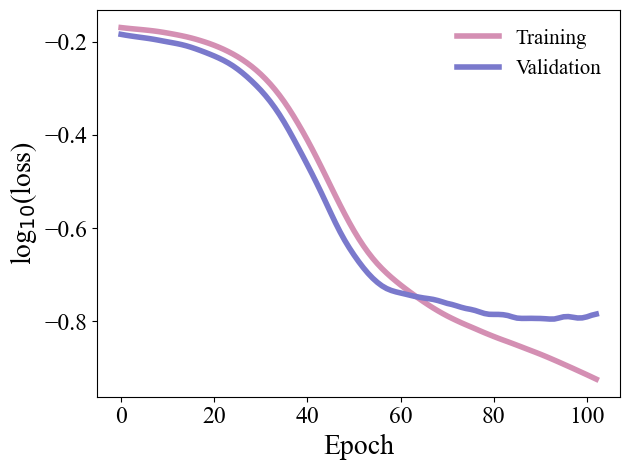

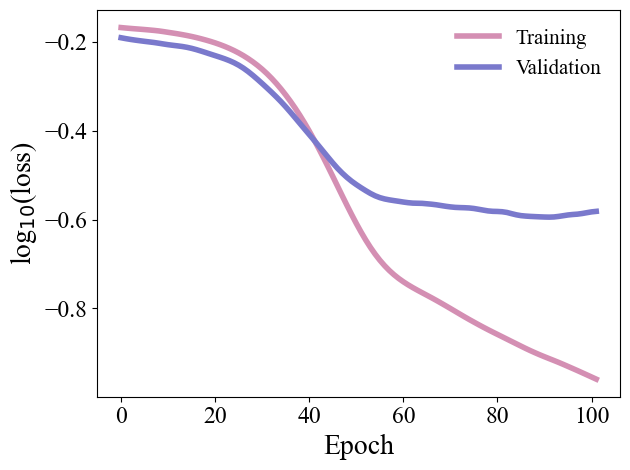

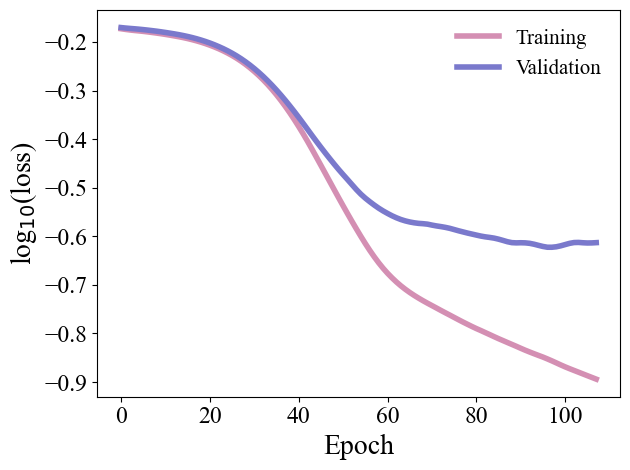

In [196]:
for i in range(5):
    loss_path = f'5fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss_outputs.csv'
    save_path = f'5fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss4paper.png'
    plot_loss4paper(loss_path, save_path)

In [28]:
# plot_lc_only_cm_avg_precision(preds_df_6040.loc[lc], 
#                     f'handpicked-kfold-results/augmented_dataset_results/5fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_normed4precision_from_individ.png')

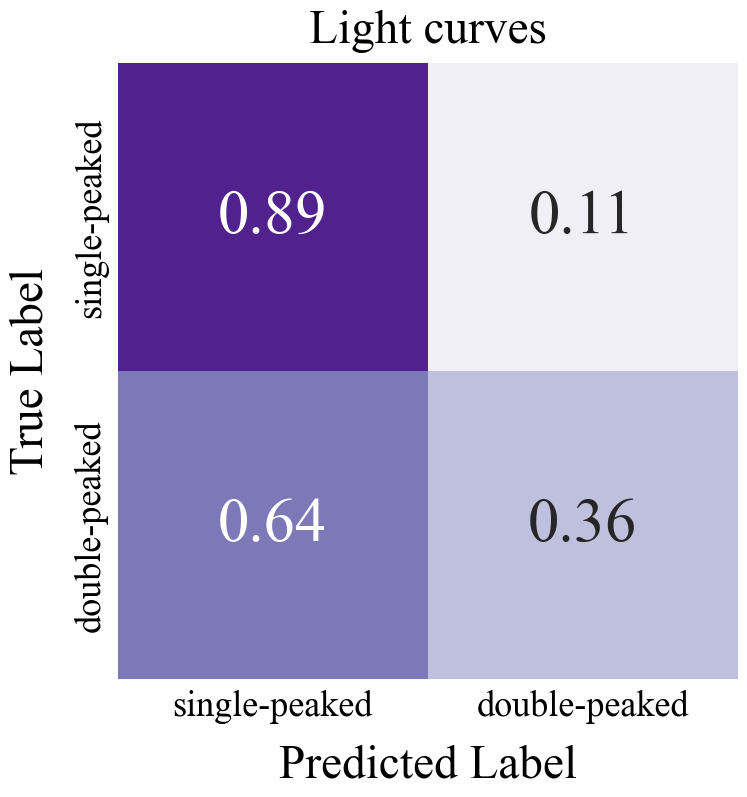

In [11]:
# making the CM averaged across folds for light curves only
%matplotlib inline
plot_lc_only_cm_avg(preds_df_6040.loc[lc], 
                    f'handpicked-kfold-results/augmented_dataset_results/5fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_from_individ.png')

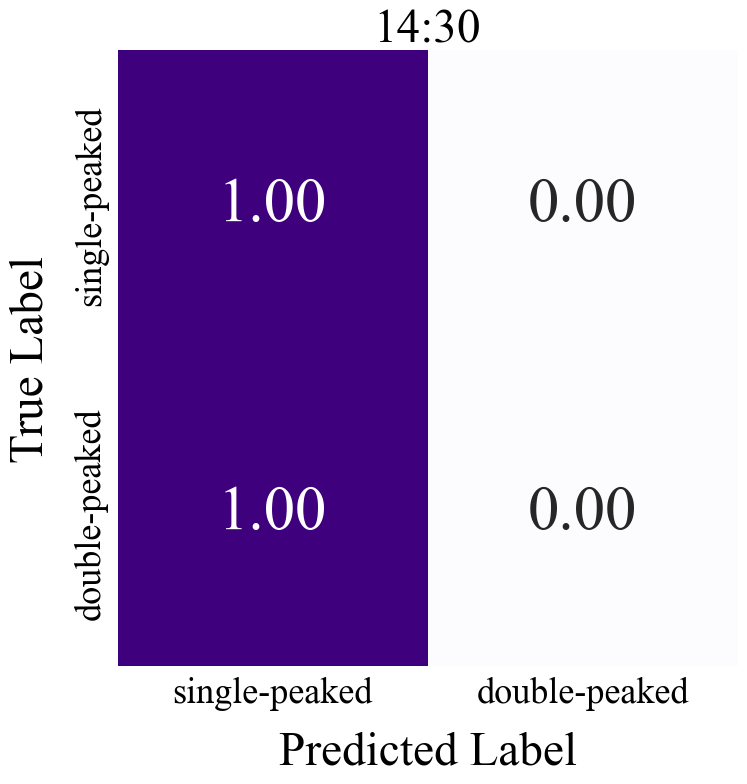

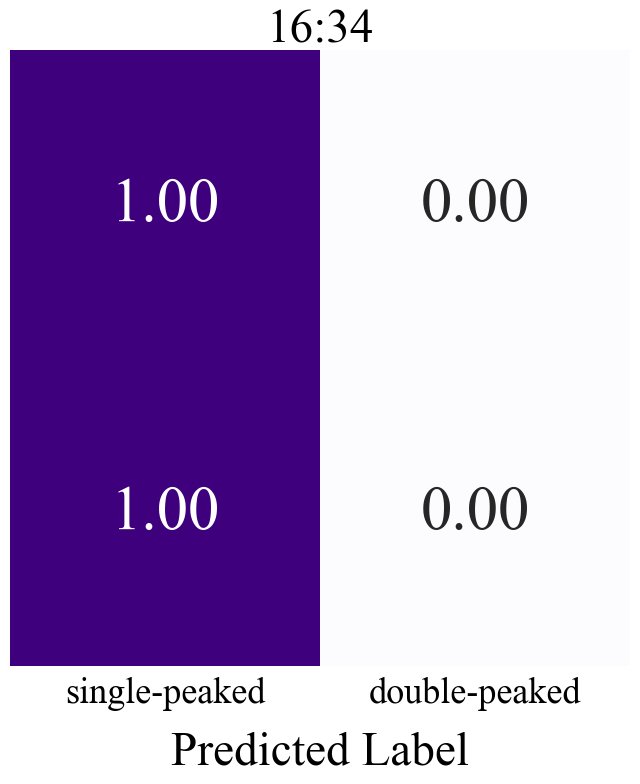

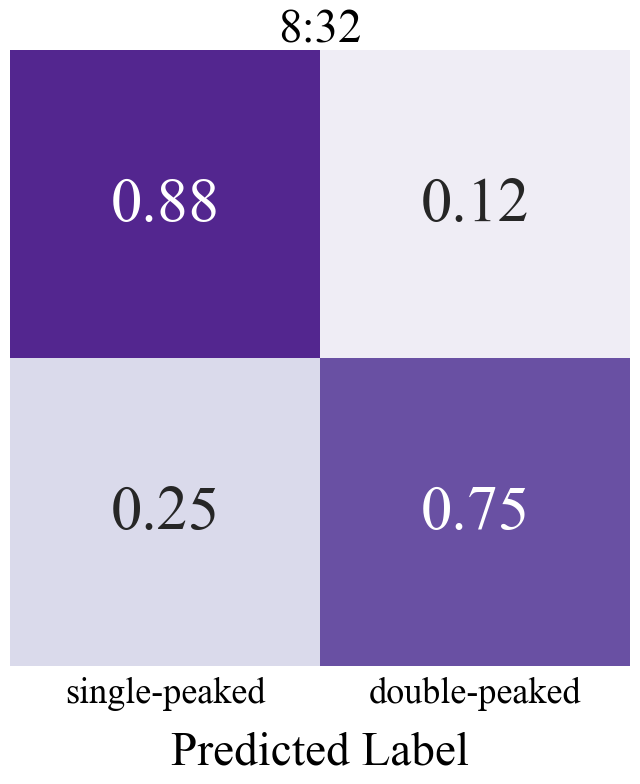

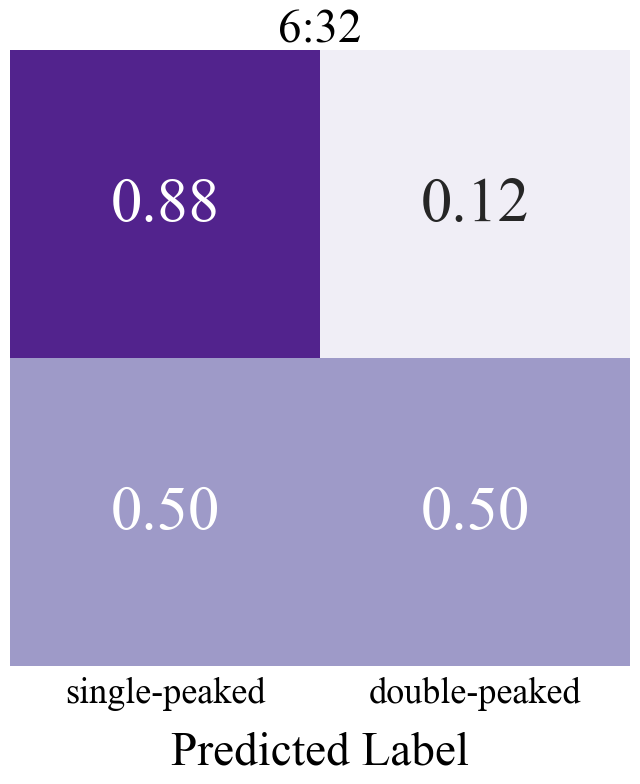

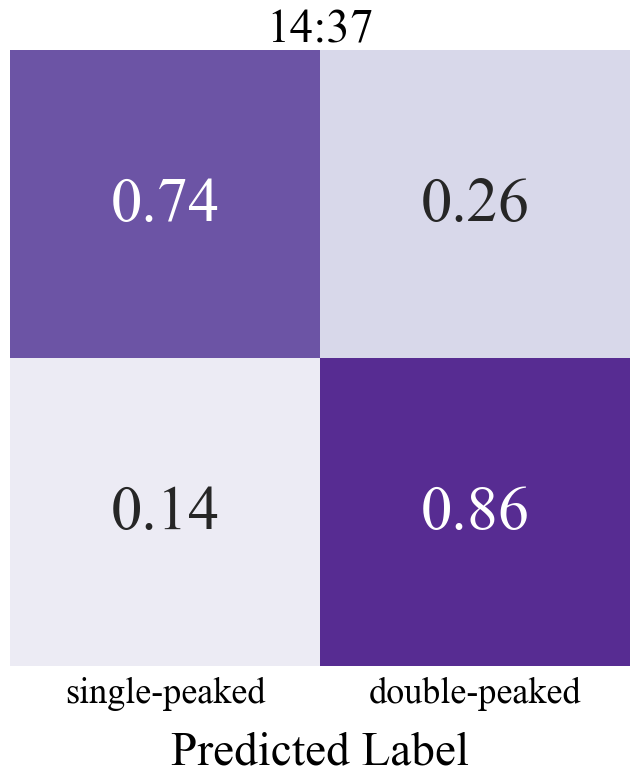

In [22]:
# making the CM for each fold
for i,fold in enumerate([kfold1,kfold2,kfold3,kfold4,kfold5]):
    plot_lc_only_per_fold(preds_df_6040, lc, i, fold, 
                        f'handpicked-kfold-results/augmented_dataset_results/5fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_fold{i}_from_individ.png',
                        display_ratio=True)

In [183]:
################################################################
#
#
# confusion matrices for the augmented 50/50 dataset - handpicked
#
#
################################################################

In [197]:
# # post-aug (i.e. w/ GP objs) and equal split
model_label =  'multipeak-finetune-cFrF-picked-kfolds-aug-3fold'
mlp_weight = 1.0
datadir = 'equalsplit'

preds_df_equal, models_equal, labels_equal, ids_equal = read_in_maven_predictions(model_label, mlp_weight, datadir)

loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold
loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold
loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold


In [198]:
# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df_equal['true_label'] == 0)
dp = ~sp

correct = (preds_df_equal['true_label']==preds_df_equal['prediction'])
incorrect = ~correct

lc = (preds_df_equal['modality']=='lightcurve')
spec = (preds_df_equal['modality']=='spectral')
lcnspec = (preds_df_equal['modality']=='lightcurveandspectral')

kfold1 = (preds_df_equal['kfold_for_val']==0)
kfold2 = (preds_df_equal['kfold_for_val']==1)
kfold3 = (preds_df_equal['kfold_for_val']==2)

Random seed: 0
n_classes 2
Loading light curves...


  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:00<00:00, 423.77it/s]


Loading spectra ...


100%|██████████| 78/78 [00:00<00:00, 1183.07it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 38/38 [00:00<00:00, 460.15it/s]


Loading spectra ...


100%|██████████| 38/38 [00:00<00:00, 1132.27it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold
Using data modalities: ['lightcurve', 'spectral']


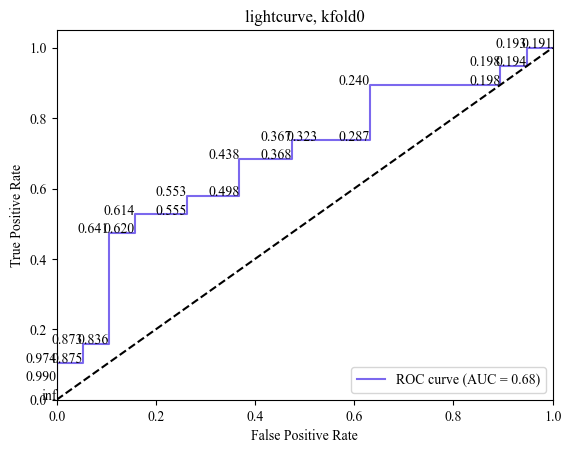

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 77/77 [00:00<00:00, 650.14it/s]


Loading spectra ...


100%|██████████| 77/77 [00:00<00:00, 1715.64it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 39/39 [00:00<00:00, 591.75it/s]


Loading spectra ...


100%|██████████| 39/39 [00:00<00:00, 2183.43it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold
Using data modalities: ['lightcurve', 'spectral']


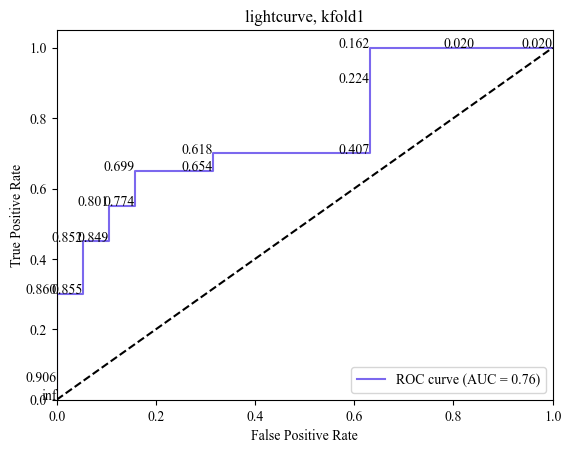

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 77/77 [00:00<00:00, 672.66it/s]


Loading spectra ...


100%|██████████| 77/77 [00:00<00:00, 2145.45it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 39/39 [00:00<00:00, 654.59it/s]


Loading spectra ...


100%|██████████| 39/39 [00:00<00:00, 2177.18it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold
Using data modalities: ['lightcurve', 'spectral']


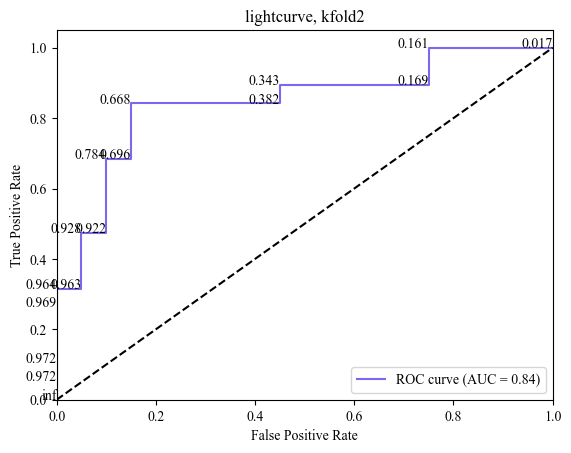

In [74]:
calc_roc_auc(models_equal, labels_equal, ids_equal, datadir, model_label)

In [182]:
# # preds_df_equal[lc].to_csv('./equal_handpicked_df.csv', index=False)
# import pandas as pd
# import numpy as np
# from sklearn.manifold import TSNE
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# import matplotlib.pyplot as plt

# # --- Load data ---
# df = pd.read_csv("./equal_handpicked_df.csv")

# # --- Feature engineering ---
# df["modality_enc"] = LabelEncoder().fit_transform(df["modality"])
# df["type_enc"] = LabelEncoder().fit_transform(df["type"])

# # Select features for t-SNE (drop identifiers and the target)
# feature_cols = ["true_label", "prediction", "modality_enc", "type_enc",
#                 "kfold_of_pred", "kfold_for_val"]

# X = df[feature_cols].values
# y = df["simulated"].astype(int).values  # 0 = real, 1 = simulated
# true_label = df["true_label"].astype(int).values

# # --- Scale ---
# X_scaled = StandardScaler().fit_transform(X)

# # --- t-SNE ---
# tsne = TSNE(
#     n_components=2,
#     perplexity=5,
#     max_iter=1000,
#     random_state=42,
#     init="pca",
# )
# X_2d = tsne.fit_transform(X_scaled)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(8, 6))

# colors = {0: "#4C72B0", 1: "#DD8452"}
# labels = {0: "Non-simulated", 1: "Simulated"}

# for sim_val in [0, 1]:
#     for tl_val in [0, 1]:
#         mask = (y == sim_val) & (true_label == tl_val)
#         if not mask.any():
#             continue

#         edgecolor = "black" if tl_val == 1 else "None"

#         # Only add a legend entry for the first true_label group per sim class
#         legend_label = labels[sim_val] if tl_val == 0 or tl_val == 2 else None

#         ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
#                    c=colors[sim_val],
#                    label=labels[sim_val],
#                    alpha=0.3,
#                    edgecolors=edgecolor,
#                    linewidths=1.2,
#                    s=90)

# # Add a proxy artist to explain the black outline
# from matplotlib.lines import Line2D
# outline_proxy = Line2D([0], [0], marker='o', color='w',
#                        markerfacecolor='None', markeredgecolor='black',
#                        markeredgewidth=1.2, markersize=10)

# handles, legend_labels = ax.get_legend_handles_labels()
# ax.legend(handles + [outline_proxy], legend_labels + ['double-peaked'])
# ax.set_title("t-SNE — Simulated vs Non-Simulated")
# ax.set_xlabel("t-SNE 1")
# ax.set_ylabel("t-SNE 2")
# plt.tight_layout()
# # plt.savefig("tsne_plot.png", dpi=150)
# plt.show()

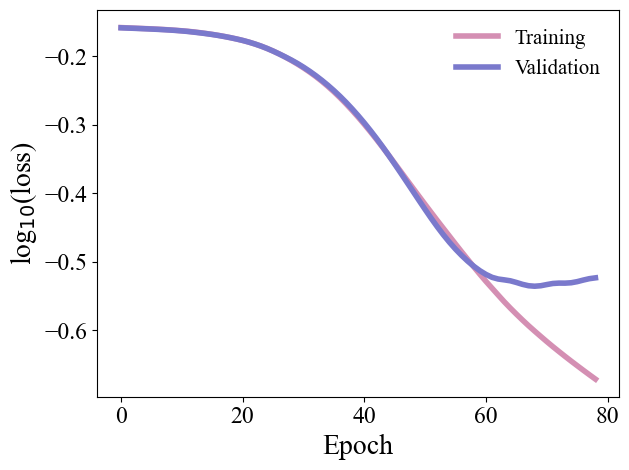

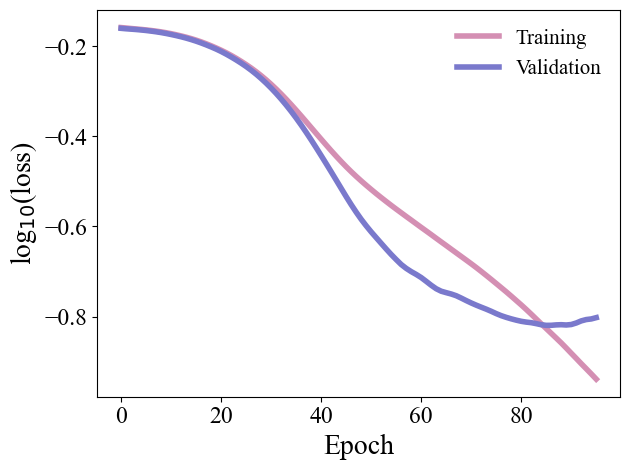

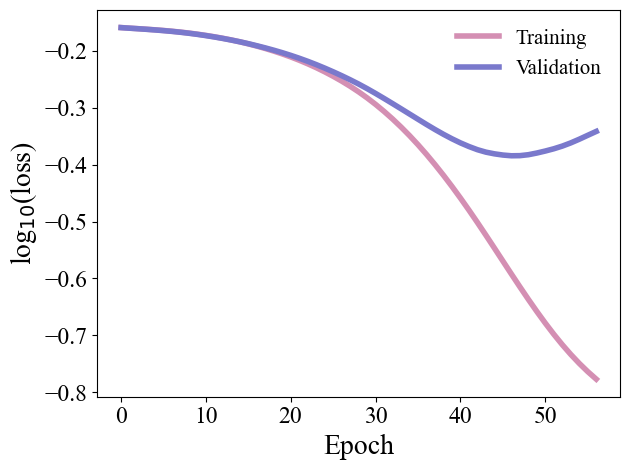

In [199]:
for i in range(3):
    loss_path = f'3fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss_outputs.csv'
    save_path = f'3fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss4paper.png'
    plot_loss4paper(loss_path, save_path)

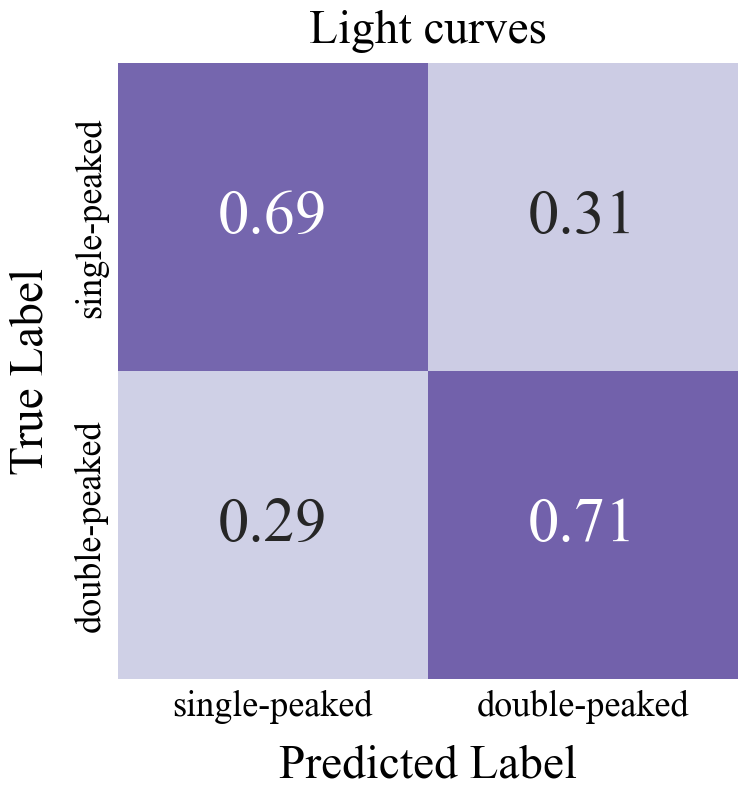

In [439]:
# making the CM averaged across foldsfor light curves only
plot_lc_only_cm_avg(preds_df_equal.loc[lc], f'handpicked-kfold-results/augmented_dataset_results/3fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_from_individ.png')

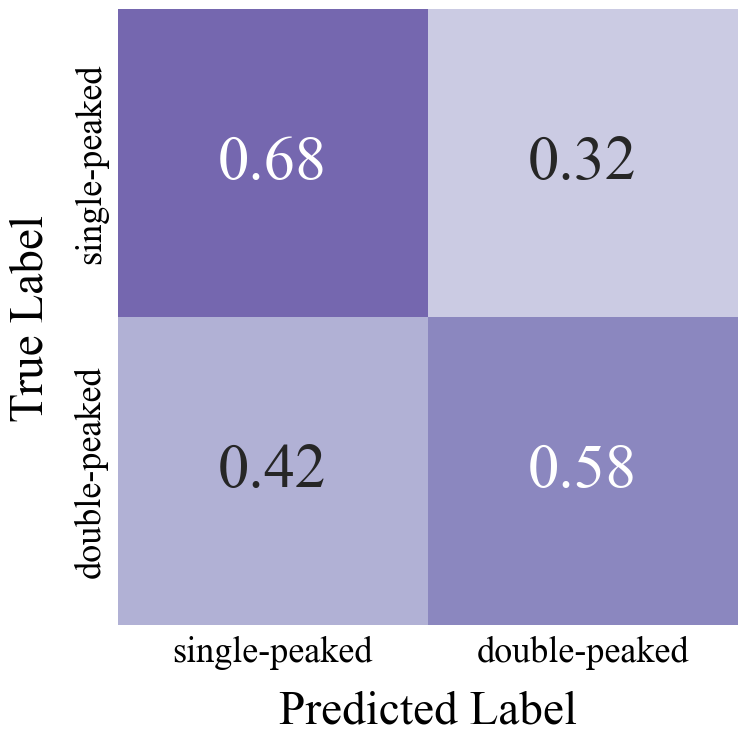

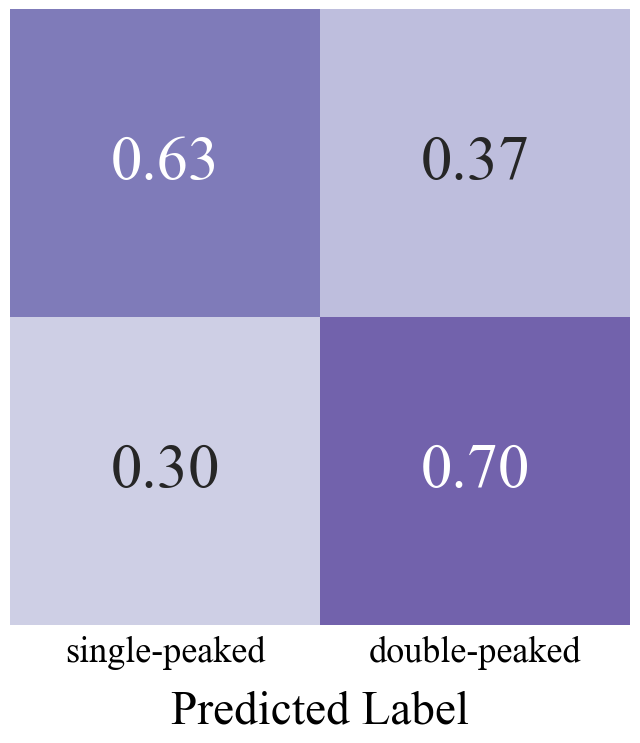

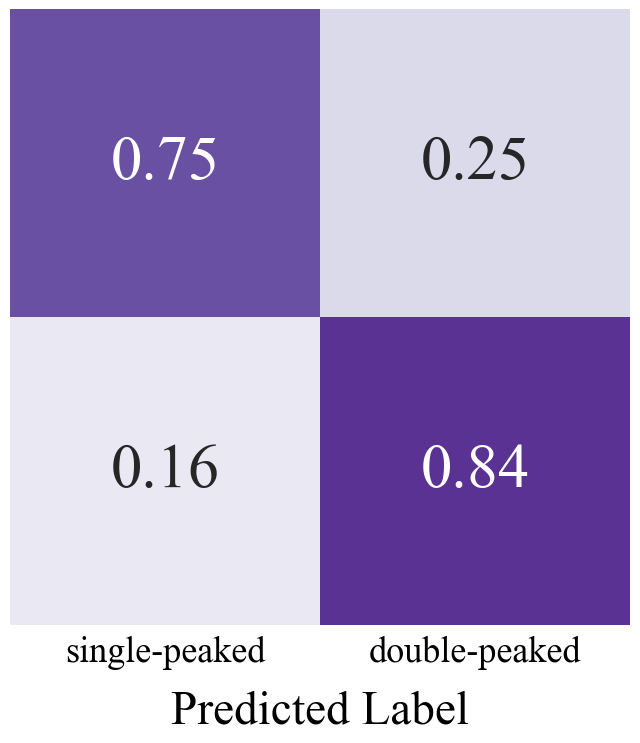

In [442]:
# making the CM for each fold
for i,fold in enumerate([kfold1,kfold2,kfold3]):
    plot_lc_only_per_fold(preds_df_equal, lc, i, fold, 
                        f'handpicked-kfold-results/augmented_dataset_results/3fold-results/per-fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_fold{i}_from_individ.png',
                        display_ratio=False)

In [177]:
################################################################
#
#
# confusion matrices for the augmented 50/50 dataset - random
#
#
################################################################

In [200]:
# # post-aug (i.e. w/ GP objs) and equal split
model_label =  'multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop'
mlp_weight = 1.0
datadir = 'equalsplit_randdrop'

preds_df_equal_randdrop, models_rand, labels_rand, ids_rand = read_in_maven_predictions(model_label, mlp_weight, datadir)

loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop
loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop
loading multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop


In [201]:
sp = (preds_df_equal_randdrop['true_label'] == 0)
dp = ~sp

correct = (preds_df_equal_randdrop['true_label']==preds_df_equal_randdrop['prediction'])
incorrect = ~correct

lc = (preds_df_equal_randdrop['modality']=='lightcurve')
spec = (preds_df_equal_randdrop['modality']=='spectral')
lcnspec = (preds_df_equal_randdrop['modality']=='lightcurveandspectral')

kfold1 = (preds_df_equal_randdrop['kfold_for_val']==0)
kfold2 = (preds_df_equal_randdrop['kfold_for_val']==1)
kfold3 = (preds_df_equal_randdrop['kfold_for_val']==2)

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 79/79 [00:00<00:00, 453.08it/s]


Loading spectra ...


100%|██████████| 79/79 [00:00<00:00, 1233.30it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 37/37 [00:00<00:00, 490.96it/s]


Loading spectra ...


100%|██████████| 37/37 [00:00<00:00, 1291.26it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop
Using data modalities: ['lightcurve', 'spectral']


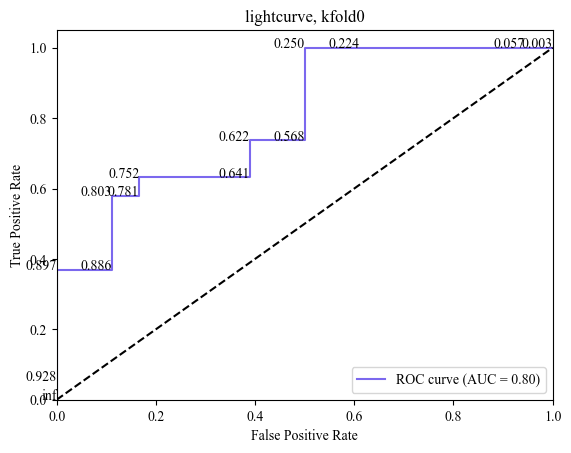

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 78/78 [00:00<00:00, 667.79it/s]


Loading spectra ...


100%|██████████| 78/78 [00:00<00:00, 2098.81it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 38/38 [00:00<00:00, 648.60it/s]


Loading spectra ...


100%|██████████| 38/38 [00:00<00:00, 2185.31it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop
Using data modalities: ['lightcurve', 'spectral']


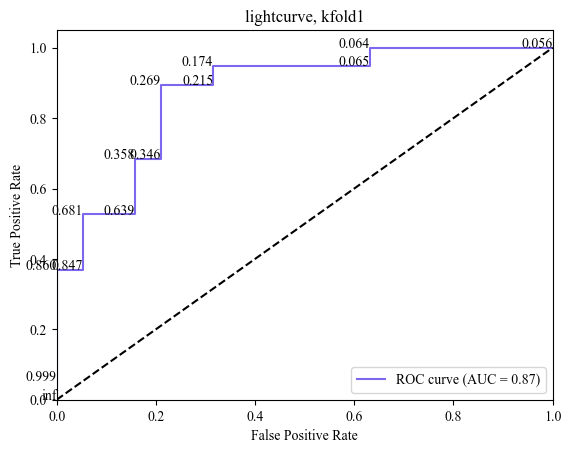

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 78/78 [00:00<00:00, 683.71it/s]


Loading spectra ...


100%|██████████| 78/78 [00:00<00:00, 2298.23it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 38/38 [00:00<00:00, 680.10it/s]


Loading spectra ...


100%|██████████| 38/38 [00:00<00:00, 1384.94it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug-3fold-randdrop
Using data modalities: ['lightcurve', 'spectral']


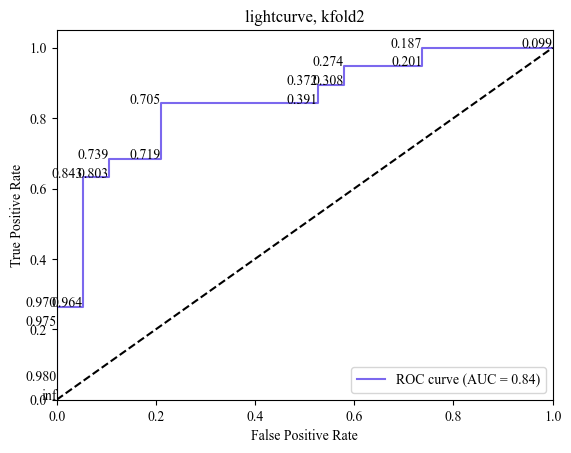

In [77]:
calc_roc_auc(models_rand, labels_rand, ids_rand, datadir, model_label)

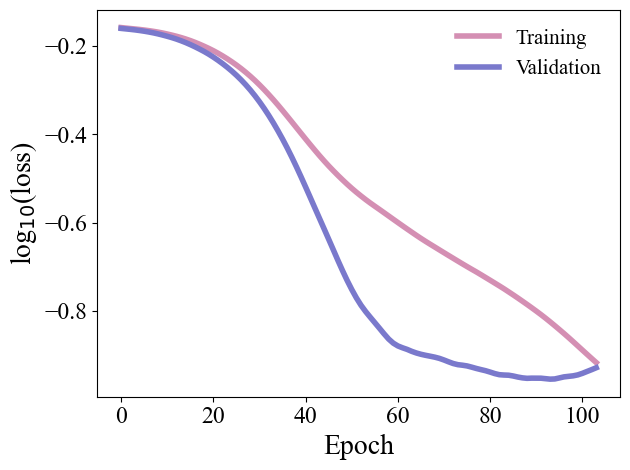

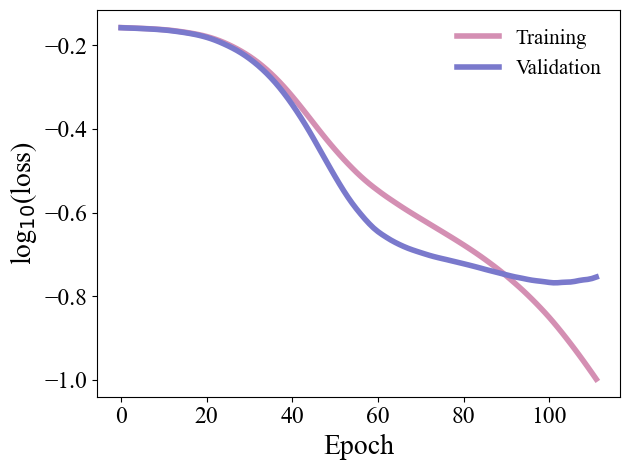

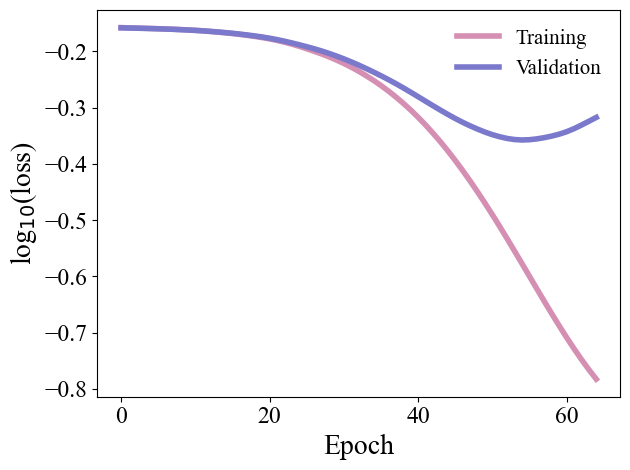

In [202]:
for i in range(3):
    loss_path = f'3fold-results/randdrop-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss_outputs.csv'
    save_path = f'3fold-results/randdrop-results/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss4paper.png'
    plot_loss4paper(loss_path, save_path)

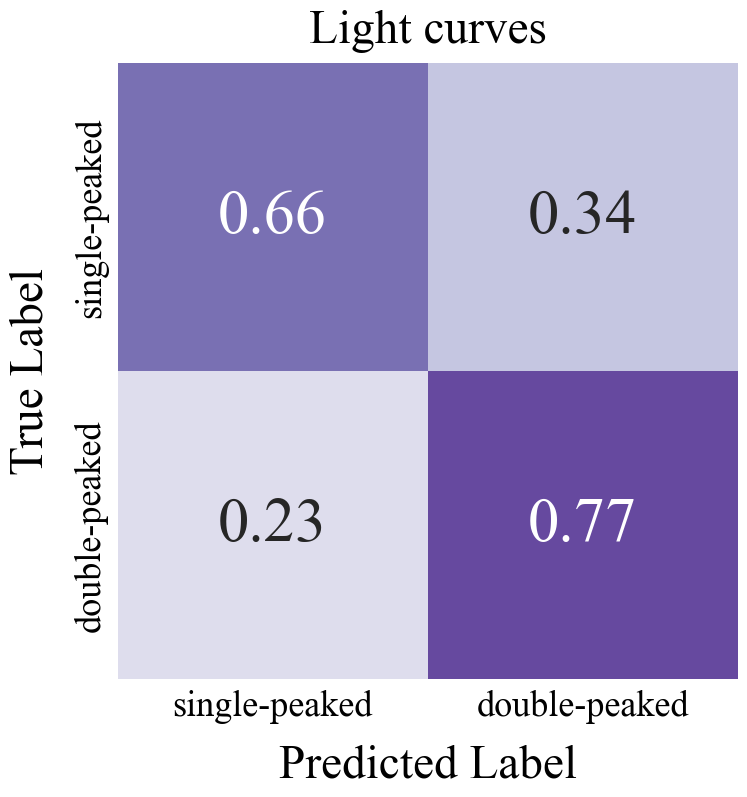

In [10]:
# making the CM averaged across foldsfor light curves only
%matplotlib inline
plot_lc_only_cm_avg(preds_df_equal_randdrop.loc[lc], 
                    f'handpicked-kfold-results/augmented_dataset_results/3fold-results/randdrop-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_from_individ.png')

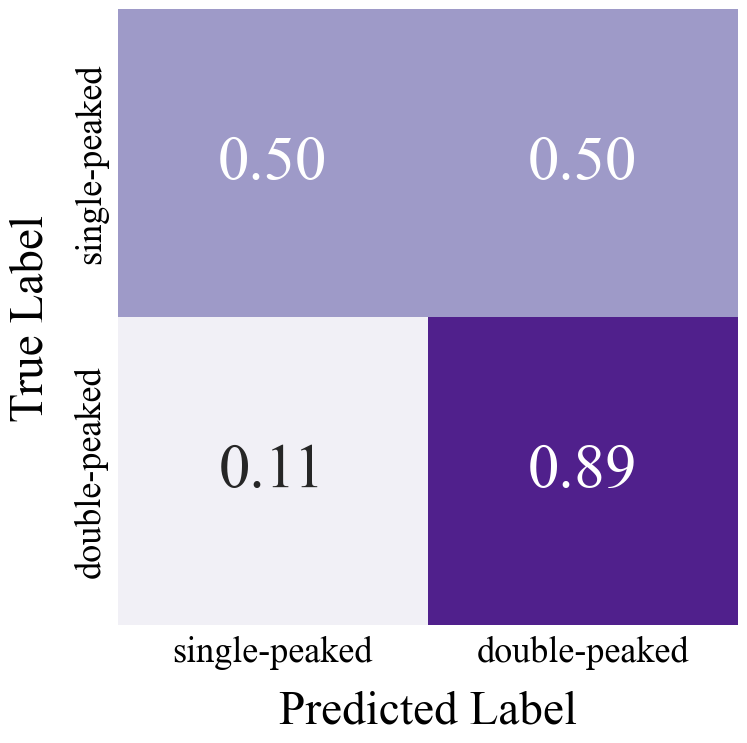

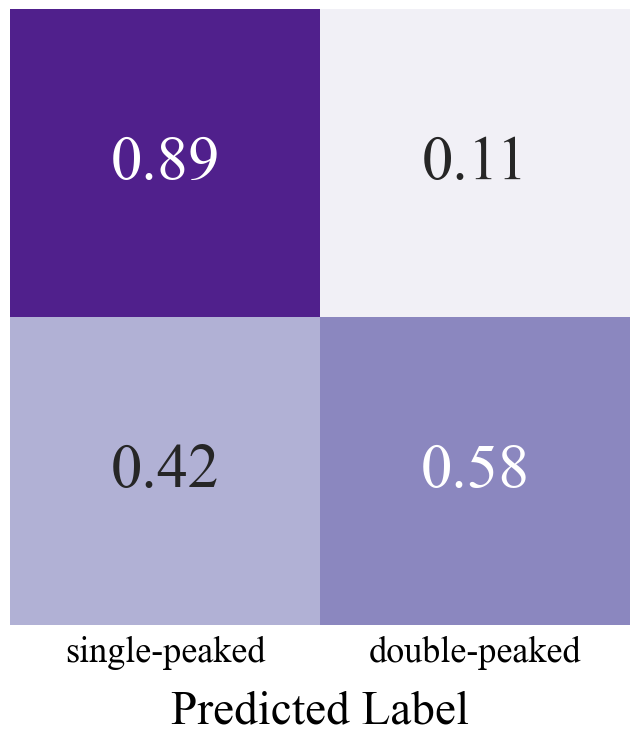

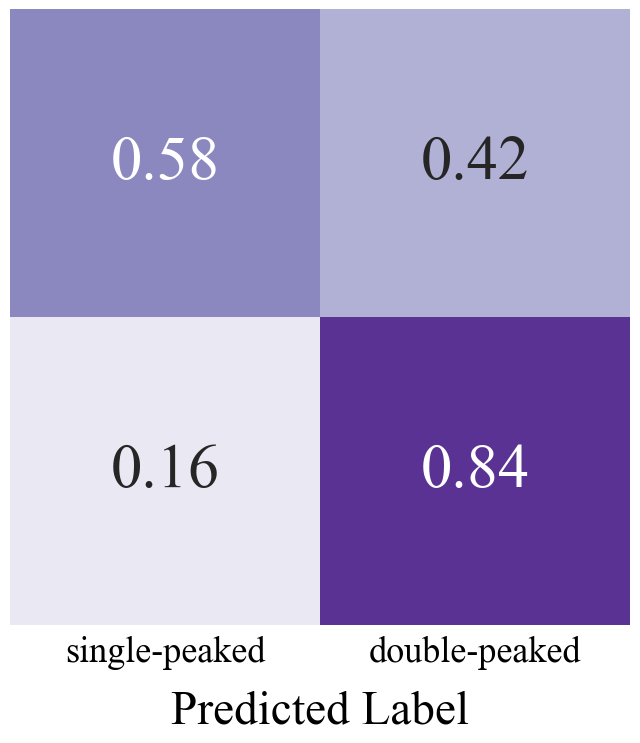

In [11]:
# making the CM for each fold
for i,fold in enumerate([kfold1,kfold2,kfold3]):
    plot_lc_only_per_fold(preds_df_equal_randdrop, lc, i, fold, 
                        f'handpicked-kfold-results/augmented_dataset_results/3fold-results/randdrop-results/per-fold-results/{model_label}+MLP+two_lightcurve_w{mlp_weight}_fold{i}_from_individ.png',
                        display_ratio=False)

In [13]:
###########################################################
#
#
#           making other plots for the paper
#
#
###########################################################

In [459]:
fiducial_dp = ['SN2020adnx', 'SN2023gwl', 'SN2024zsw']
fiducial_sp = ['SN2019pfb', 'SN2024rbc', 'SN2021lvb']
edge_case_sp = ['SN2019pof', 'SN2019lfj', 'SN2023usf']

#9010 data dirs
dataset9010 = pd.read_csv('./data/test/all_v1/ZTFBTS_TransientTable.csv')
lc_dir = './data/test/all_v1/light-curves'
spectra_dir = './data/test/all_spectra_v1'

In [460]:
dataset9010.loc[dataset9010['IAUID'].isin(fiducial_dp)]

,ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,type,redshift,double-peaked,A_V,filenames
37,ZTF20adadlqm,SN2020adnx,46.481375,41.608711,59228.405017,g,17.710078,SN IIb,NaN,1,0.390796,['ZTF20adadlqm_0']
82,ZTF23aaialcw,SN2023gwl,198.841494,1.927567,60080.237147,g,18.940516,SN IIb,0.034600,1,0.089636,['ZTF23aaialcw_0']
97,ZTF24abpdzvm,SN2024zsw,20.793617,19.570172,60632.542341,g,19.196814,SN IIb,0.032286,1,0.161435,['ZTF24abpdzvm_0']


In [461]:
dataset9010.loc[dataset9010['IAUID'].isin(fiducial_sp)]

,ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,type,redshift,double-peaked,A_V,filenames
28,ZTF19abvdgqo,SN2019pfb,294.947093,59.367999,58735.101034,g,18.188238,SN Ib,0.03683,0,0.252655,['ZTF19abvdgqo_0']
64,ZTF21abahiow,SN2021lvb,262.147874,21.739394,59354.048002,g,18.574318,SN Ib,0.03000,0,0.214478,['ZTF21abahiow_0']
96,ZTF24aaymkrs,SN2024rbc,3.089359,31.063392,60537.304655,g,17.396463,SN Ib,0.01600,0,0.222497,['ZTF24aaymkrs_0']


In [462]:
dataset9010.loc[dataset9010['IAUID'].isin(edge_case_sp)]

,ZTFID,IAUID,RA,Dec,peakt,peakfilt,peakmag,type,redshift,double-peaked,A_V,filenames
26,ZTF19abfiqjg,SN2019lfj,29.453205,13.176170,58685.179530,g,19.003098,SN Ic,0.0888,0,0.165620,['ZTF19abfiqjg_0']
29,ZTF19abxtcio,SN2019pof,18.157804,33.034936,58746.188449,g,18.631786,SN IIb,0.0155,0,0.185889,['ZTF19abxtcio_0']
89,ZTF23abhyxpr,SN2023usf,124.347958,21.694611,60232.639669,g,17.148292,SN Ib/c,0.0120,0,0.121078,['ZTF23abhyxpr_0']


In [568]:
import ast

plt.rcParams['axes.labelsize'] = 28    # X and Y label size
plt.rcParams['xtick.labelsize'] = 18   # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 18   # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 18   # Legend font size

# plotting LC - spectral pairs
def plot_lc_spec_pair(iauid, save=False, plot_title='', phase=''):
    fnames = dataset9010.loc[dataset9010['IAUID']==iauid, 'filenames']
    fname = [item for entry in fnames.to_list() for item in (ast.literal_eval(entry) if isinstance(entry, str) else entry)][0]

    lc_df = pd.read_csv(lc_dir+f'/{fname}.csv')
    spec_df = pd.read_csv(spectra_dir+f'/{fname}.csv', names=['wavelength', 'flux'])
    
    g = (lc_df['band']=='g')
    r = (lc_df['band']=='R')

    fig, axs = plt.subplots(1, 2, figsize=(17,5))

    # lc plot
    axs[0].errorbar(lc_df.loc[g, 'time'], lc_df.loc[g, 'mag'], yerr=lc_df.loc[g, 'magerr'],
                    ls='', marker='.', markersize=19, mfc='darkseagreen', ecolor='darkseagreen', mec='None', label='g', alpha=0.65)
    axs[0].errorbar(lc_df.loc[r, 'time'], lc_df.loc[r, 'mag'], yerr=lc_df.loc[r, 'magerr'],
                    ls='', marker='.', markersize=19, mfc='palevioletred', ecolor='palevioletred', mec='None', label='r', alpha=0.65,zorder=0)
    axs[0].invert_yaxis()
    axs[0].legend(loc='lower right', facecolor='white', edgecolor='None', framealpha=0.75)
    axs[0].set_xlabel('MJD')
    axs[0].set_ylabel('Apparent Magnitude', labelpad=10)

    #spec plot
    axs[1].step(spec_df['wavelength'], spec_df['flux'],color='darkslategray', alpha=0.8)
    axs[1].set_xlabel(r'Wavelength [$\AA$]')
    axs[1].set_ylabel('Normalized Flux')

    #kwargs
    axs[0].tick_params(axis='both', direction='in')
    axs[1].tick_params(axis='both', direction='in')
    axs[1].annotate(phase, xy=(0.34,0.075), xycoords='axes fraction', fontsize=20, color='gray')
    plt.suptitle(iauid, fontsize=30, pad=10)

    if save:
        plt.savefig(f'./figures/{plot_title}.png', dpi=300, bbox_inches='tight')

    plt.show()
    return

In [569]:
# for name in fiducial_dp:
#     plot_lc_spec_pair(name)

In [570]:
# for name in fiducial_sp:
#     plot_lc_spec_pair(name)

In [571]:
# for name in edge_case_sp:
#     plot_lc_spec_pair(name)

AttributeError: 'Text' object has no property 'pad'

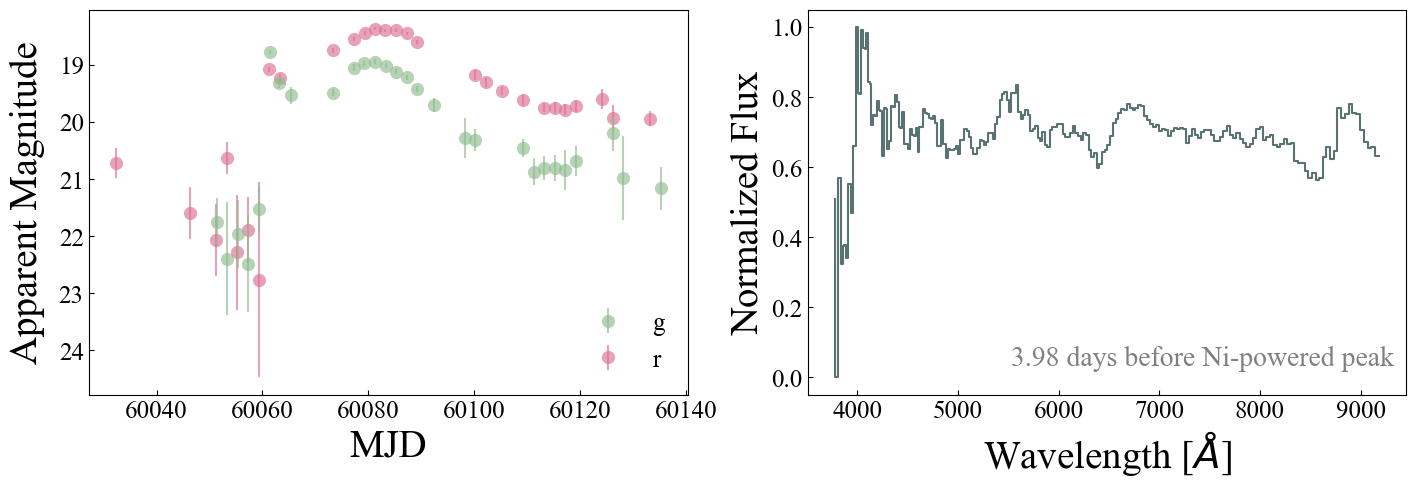

In [572]:
plot_lc_spec_pair(fiducial_dp[1], save=True, plot_title=f'fiducial_dp_obj_lc_spec_{fiducial_dp[1]}', phase='3.98 days before Ni-powered peak')
plot_lc_spec_pair(fiducial_sp[1], save=True, plot_title=f'fiducial_sp_obj_lc_spec_{fiducial_sp[1]}', phase='1.93 days before Ni-powered peak')
# plot_lc_spec_pair(edge_case_sp[1], save=True, plot_title=f'fiducial_edgecase_obj_lc_spec_{edge_case_sp[1]}')

# add in phase of spectrum to plot
    # SN 2023gwl: 3.98 days before Ni-powered peak
    # SN 2024rbc: 1.93 days before Ni-powered peak

In [ ]:
#maing small multiples of all the lc in each fold of the augmented dataset

In [203]:
# post-aug (i.e. w/ GP objs)
model_label =  'multipeak-finetune-cFrF-picked-kfolds-aug'
mlp_weight = 1.0
datadir = 'all'

preds_df_6040, models, labels, ids = read_in_maven_predictions(model_label, mlp_weight, datadir)

# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df_6040['true_label'] == 0)
dp = ~sp

correct = (preds_df_6040['true_label']==preds_df_6040['prediction'])
incorrect = ~correct

lc = (preds_df_6040['modality']=='lightcurve')
spec = (preds_df_6040['modality']=='spectral')
lcnspec = (preds_df_6040['modality']=='lightcurveandspectral')

kfold1 = (preds_df_6040['kfold_for_val']==0)
kfold2 = (preds_df_6040['kfold_for_val']==1)
kfold3 = (preds_df_6040['kfold_for_val']==2)
kfold4 = (preds_df_6040['kfold_for_val']==3)
kfold5 = (preds_df_6040['kfold_for_val']==4)

loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug


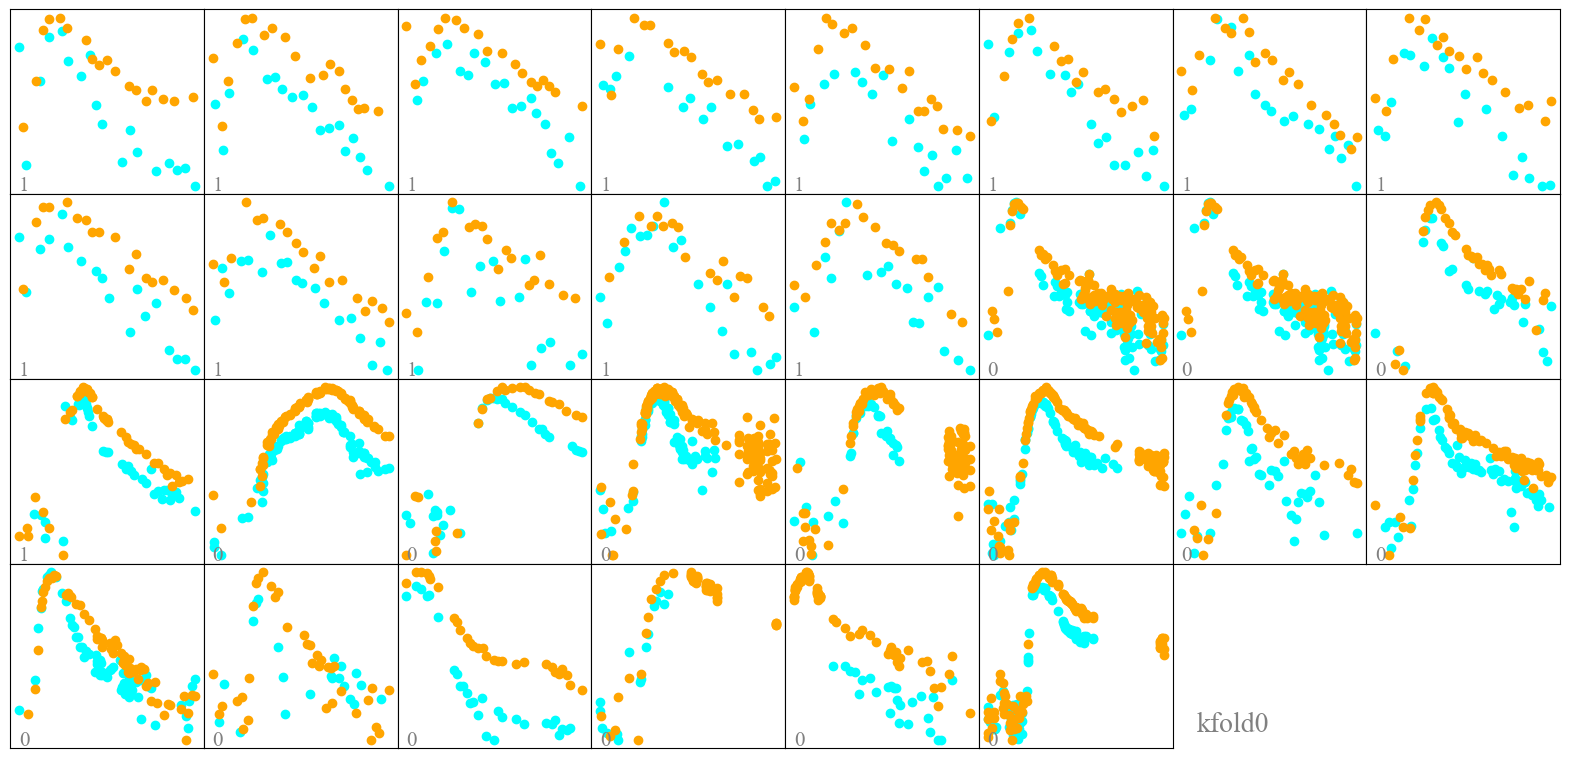

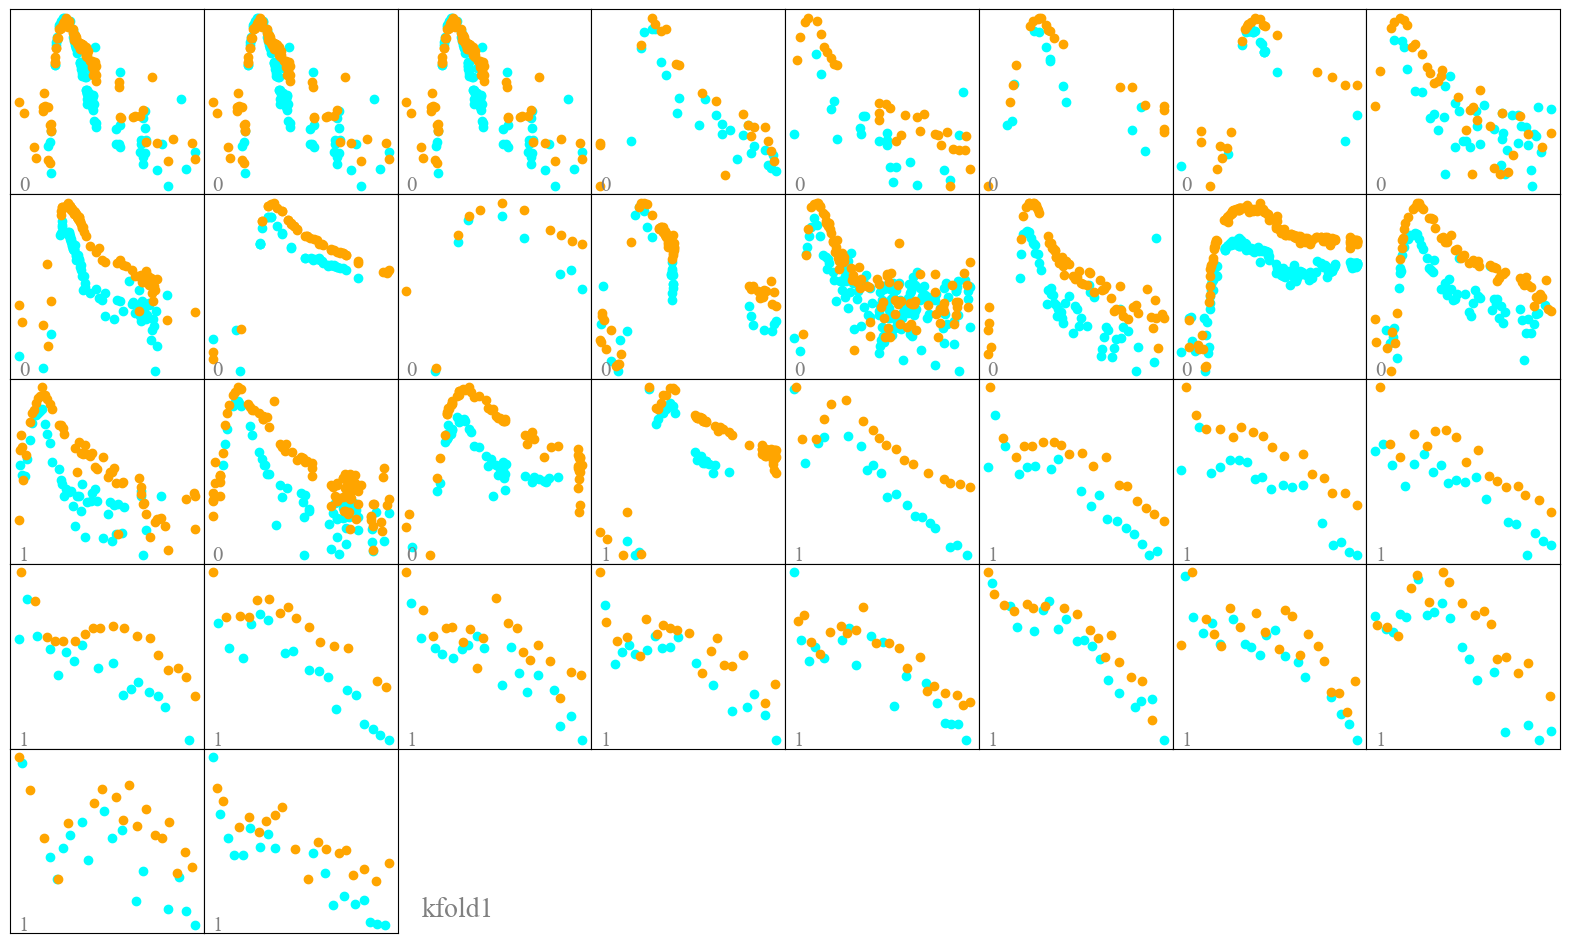

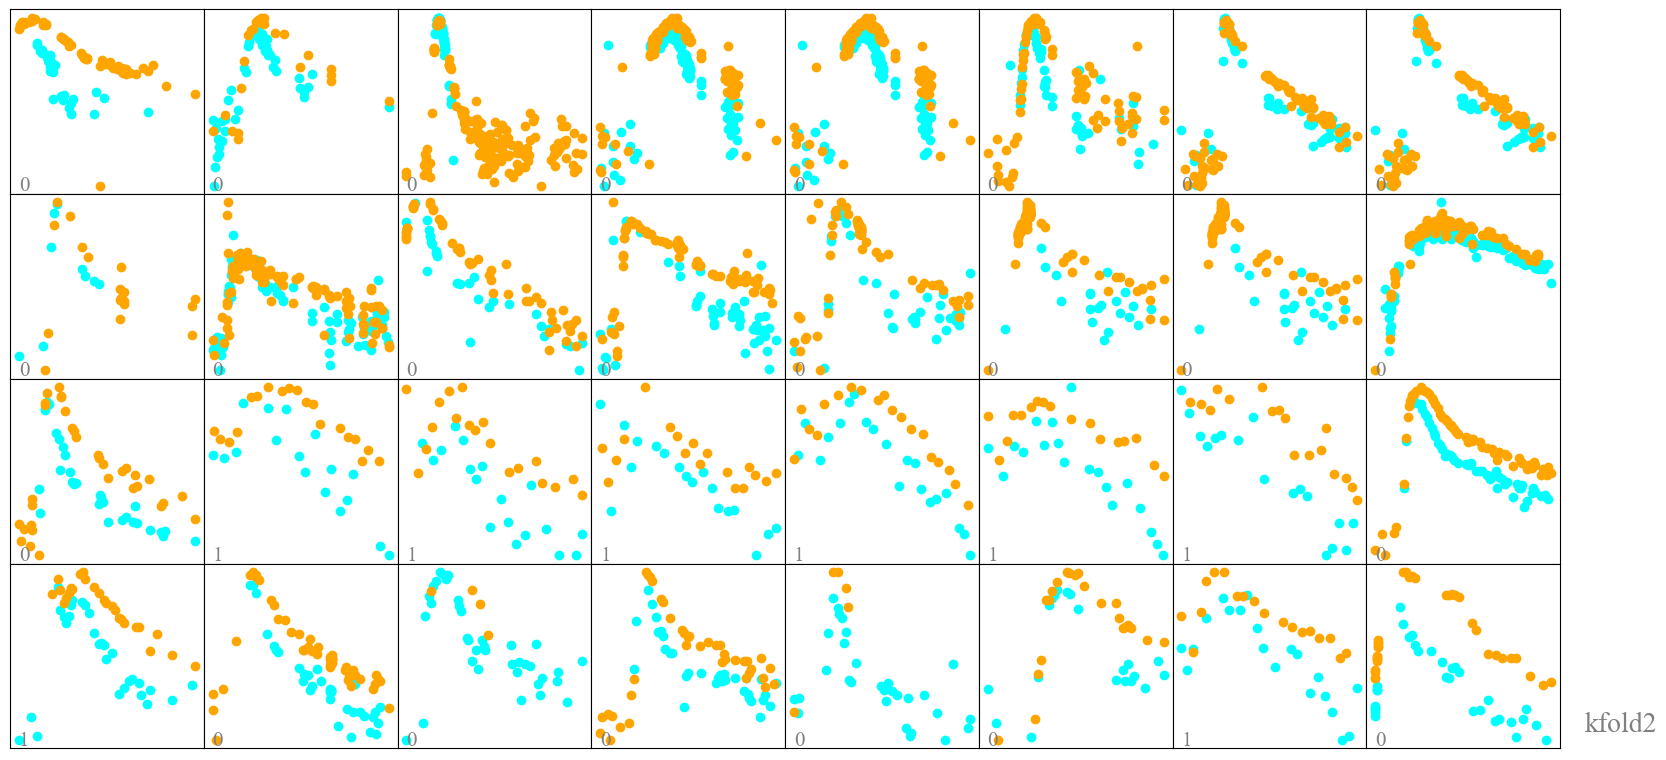

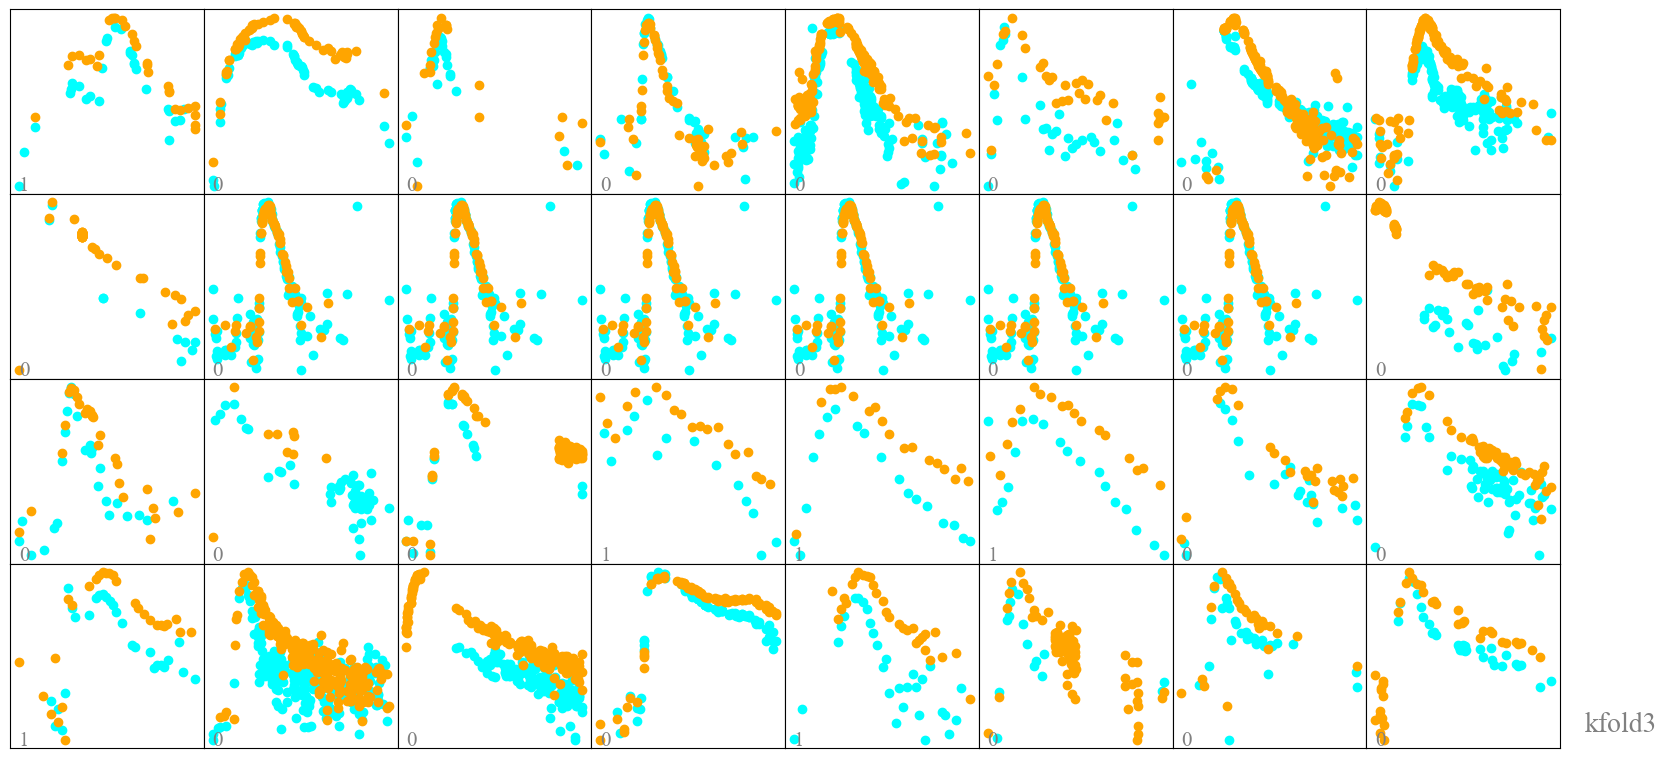

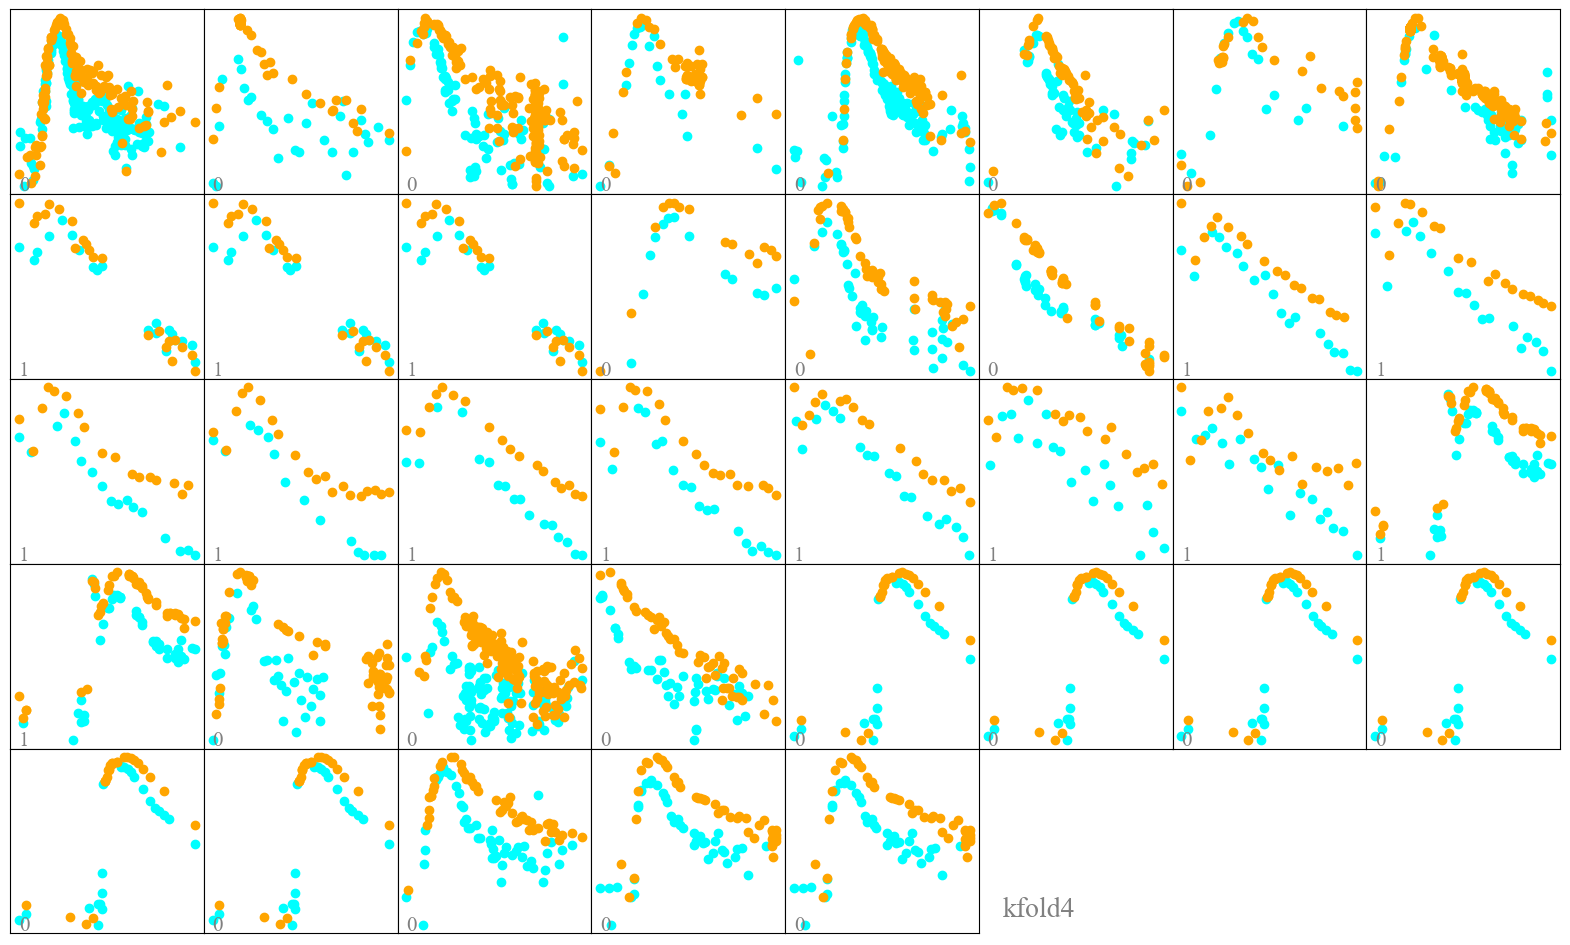

In [243]:
for i,fold in enumerate([kfold1,kfold2,kfold3,kfold4,kfold5]):
    lc_fnames = preds_df_6040.loc[lc&fold, 'SN']
    true_labels = preds_df_6040.loc[lc & fold, 'true_label'].values

    fig, axes = plt.subplots(5, 8, figsize=(20, 12))
    fig.subplots_adjust(hspace=0, wspace=0)
    axes = axes.flatten()
    
    for j,fname in enumerate(lc_fnames):
        lc_df = pd.read_csv(f'./data/test/{datadir}/light-curves/{fname}.csv') # cols = time,mag,magerr,band

        ax = axes[j]
        ax.scatter(lc_df.loc[lc_df['band']=='g', 'time'], lc_df.loc[lc_df['band']=='g', 'mag'], color='cyan')
        ax.scatter(lc_df.loc[lc_df['band']=='R', 'time'], lc_df.loc[lc_df['band']=='R', 'mag'], color='orange')
        ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        ax.invert_yaxis()

        ax.annotate(true_labels[j], xy=(0.1, 0.1), xycoords='axes fraction',
            ha='right', va='top', fontsize=15, color='gray')
        
        # hide unused subplots
        for k in range(len(lc_fnames), len(axes)):
            axes[k].set_visible(False)
    
    # plt.tight_layout()
    ax.annotate(f'kfold{i}', xy=(1.5, 0.2), xycoords='axes fraction',
            ha='right', va='top', fontsize=20, color='gray')
    plt.savefig(f'./figures/small_multiples_lc_augmented_dataset_kfold{i}.png', dpi=300)
    plt.show()

In [244]:
# testing new seed on augmented dataset performance

In [9]:
model_label = 'multipeak-finetune-cFrF-picked-kfolds-aug'
mlp_weight = 1.0
datadir = 'all'

#read in individual object predictions from evaluate_models_single output
preds_df = pd.read_csv(f'./{model_label}+MLP+two_w{mlp_weight}_seed434_single_objs.csv')

#read in dataset dsecription
dataset = pd.read_csv(f'./data/test/{datadir}/ZTFBTS_TransientTable.csv')

# creating placeholder column for the k-fold for which the obj belongs to the validation set for
preds_df['kfold_for_val'] = [0]*len(preds_df)

#loading in models and validation sets
directories = [
    f"models/{model_label}",
]  
names = [
    f"{model_label}",
]
models = []

paths = []
ids = []
labels = []
# Finding all checkpoints
for id, (directory, label) in enumerate(zip(directories, names)):
    paths_to_checkpoint, name, id = get_checkpoint_paths(directory, label, id)
    paths.extend(paths_to_checkpoint)
    ids.extend(id)
    labels.extend(name)

for i, path in enumerate(paths):
    print(f"loading {labels[i]}")
    # print(path)
    models.append(load_model(path))

# if obj appears in list of val_filenames from model, then update k-fold_in_valid to the model i we are on
for i in range(len(models)):
    val_filenames = models[i][-1]
    preds_df.loc[preds_df['SN'].isin(val_filenames), 'kfold_for_val'] = i

#cross-matching objects between DFs to add SN type to preds_df
types = []
for i,sn in enumerate(preds_df['SN'][::3]):
    sn_ztf = sn[:12]
    snt = dataset.loc[dataset.ZTFID==sn_ztf, 'type'].iloc[0]
    types.append([snt]*3)

preds_df['type'] = np.array(types).flatten()

preds_df.loc[preds_df['type']=='SN Ib/c', 'type'] = 'SN Ibc'

loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug


In [10]:
# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df['true_label'] == 0)
dp = ~sp

correct = (preds_df['true_label']==preds_df['prediction'])
incorrect = ~correct

lc = (preds_df['modality']=='lightcurve')
spec = (preds_df['modality']=='spectral')
lcnspec = (preds_df['modality']=='lightcurveandspectral')

kfold1 = (preds_df['kfold_for_val']==0)
kfold2 = (preds_df['kfold_for_val']==1)
kfold3 = (preds_df['kfold_for_val']==2)
kfold4 = (preds_df['kfold_for_val']==3)
kfold5 = (preds_df['kfold_for_val']==4)

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 135/135 [00:00<00:00, 626.41it/s]


Loading spectra ...


100%|██████████| 135/135 [00:00<00:00, 2285.32it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 30/30 [00:00<00:00, 567.00it/s]


Loading spectra ...


100%|██████████| 30/30 [00:00<00:00, 1782.94it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
thresholds: [       inf 0.39260992 0.3913653  0.39107785 0.38936082 0.3838104
 0.3834147  0.38321003 0.38302264 0.3818021  0.38170192 0.38140196
 0.38054016 0.3804206  0.37959746 0.37945196 0.37915525 0.3790051
 0.37705866 0.37489665]


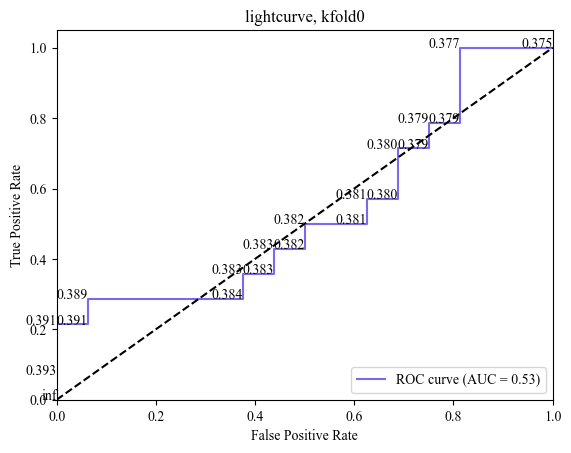

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 131/131 [00:00<00:00, 673.64it/s]


Loading spectra ...


100%|██████████| 131/131 [00:00<00:00, 2390.29it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 34/34 [00:00<00:00, 675.77it/s]


Loading spectra ...


100%|██████████| 34/34 [00:00<00:00, 2171.43it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
thresholds: [       inf 0.40190145 0.39826706 0.39587265 0.3952643  0.39461836
 0.39461765 0.3943911  0.392261   0.39215913 0.39192238 0.39125437
 0.39115143 0.39063522 0.389962   0.38977283 0.38724327 0.3869578 ]


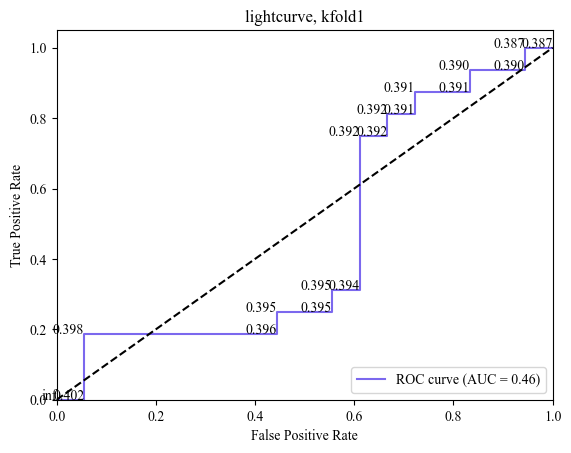

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 630.15it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2173.27it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 684.25it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 2131.93it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
thresholds: [          inf 9.5712501e-01 9.2350829e-01 9.2320466e-01 8.4660274e-01
 4.6577844e-01 3.4415174e-01 1.5506051e-01 7.6940589e-02 6.3814104e-02
 4.0865045e-02 7.4416440e-04]


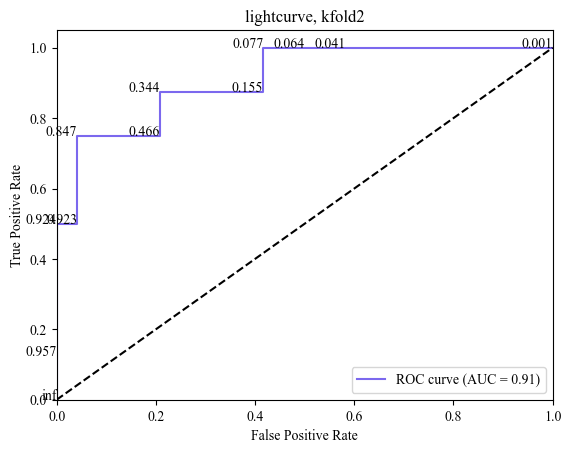

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 671.91it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2329.29it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 624.71it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 2230.72it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
thresholds: [       inf 0.489281   0.41975117 0.41079828 0.384553   0.3820214
 0.35868594 0.35861343 0.35737264 0.356175   0.31674114]


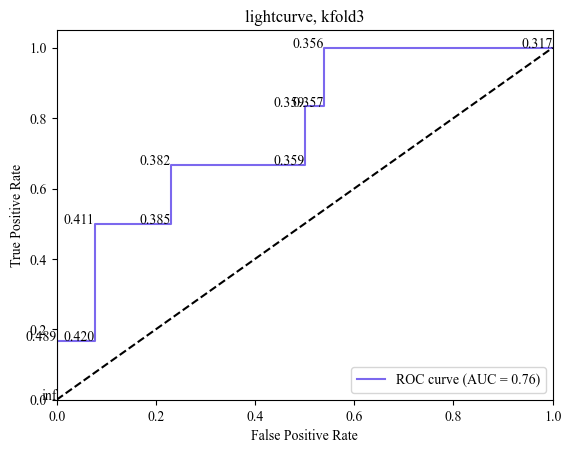

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 128/128 [00:00<00:00, 659.11it/s]


Loading spectra ...


100%|██████████| 128/128 [00:00<00:00, 2396.51it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 37/37 [00:00<00:00, 670.69it/s]


Loading spectra ...


100%|██████████| 37/37 [00:00<00:00, 2238.06it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
thresholds: [       inf 0.88646483 0.88246834 0.8732377  0.86505914 0.86358863
 0.8625338  0.8613949  0.85706466 0.8351324  0.81123376 0.7521843
 0.43306565 0.4182087  0.06334935 0.05026288 0.05026285 0.01909327]


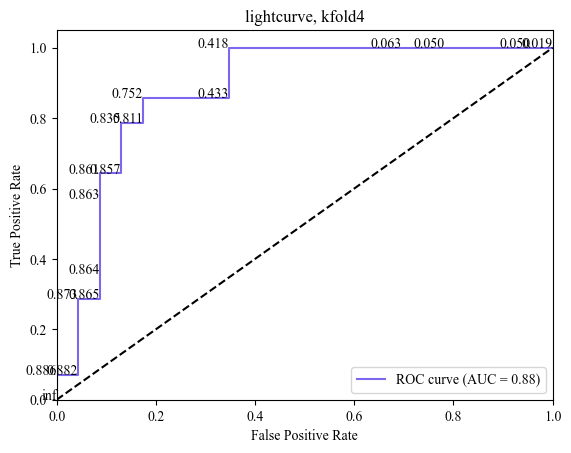

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = f'data/test/{datadir}'
spectra_dir = f'data/test/{datadir}_spectra'

kval=0
for output, label, id in zip(models, labels, ids):
    (
        model,
        combinations,
        regression,
        classification,
        n_classes,
        cfg,
        cfg_extra_args,
        train_filenames,
        val_filenames,
    ) = output

    set_seed(cfg["seed"])

    print('n_classes', n_classes)

    # Spectral data is cut to this length
    dataset_train, nband, filenames_read, _ = load_data(
        data_dir,
        spectra_dir,
        max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
        combinations=cfg_extra_args["combinations"],
        spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
        filenames=train_filenames,
        n_classes=n_classes,
        handpicked_folds=cfg_extra_args["handpicked_folds"],
        handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
    )

    # Check that the filenames read are a subset of the training filenames from the already trained models
    assert is_subset(filenames_read, train_filenames)

    dataset_val, nband, filenames_read, _ = load_data(
        data_dir,
        spectra_dir,
        max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
        combinations=cfg_extra_args["combinations"],
        spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
        filenames=val_filenames,
        n_classes=n_classes,
        handpicked_folds=cfg_extra_args["handpicked_folds"],
        handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
    )
    
    # Check that the filenames read are a subset of the training filenames from the already trained models
    assert is_subset(filenames_read, val_filenames)

    train_loader_no_aug = NoisyDataLoader(
        dataset_train,
        batch_size=cfg["batchsize"],
        noise_level_img=0,
        noise_level_mag=0,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        combinations=cfg_extra_args["combinations"],
    )

    val_loader_no_aug = NoisyDataLoader(
        dataset_val,
        batch_size=cfg["batchsize"],
        noise_level_img=0,
        noise_level_mag=0,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        combinations=cfg_extra_args["combinations"],
    )

    model = model.to(device)
    model.eval()
    
    #y_pred empty if regression is not True
    y_true, y_true_label, y_pred, lc_data = process_data_loader(
        val_loader_no_aug,
        regression,
        classification,
        device,
        model,
        combinations=cfg_extra_args["combinations"],
    )
    y_true_train, y_true_train_label, _, _ = process_data_loader(
        train_loader_no_aug,
        regression,
        classification,
        device,
        model,
        combinations=cfg_extra_args["combinations"],
    )

    print("===============================")
    print(f"Model: {label}")
    print(f"Using data modalities: {cfg_extra_args['combinations']}")
    
    embs_list, combs = get_embs(
            model, val_loader_no_aug, cfg_extra_args["combinations"], ret_combs=True
        )
    embs_list_train = get_embs(model, train_loader_no_aug, combinations)
    subclasses = torch.tensor(
        [0,1] 
    )
    embs_list, y_true_label, lc_data = filter_classes(
        embs_list, y_true_label, lc_data, subclasses
    )
    embs_list_train, y_true_train_label, _ = filter_classes(
        embs_list_train, y_true_train_label, None, subclasses
    )

    X_val, Y_val = embs_list[0], y_true_label,

    # Ensure Y is 2D (necessary for sklearn)
    if (Y_val is not None) and (len(Y_val.shape) == 1):
        Y_val = Y_val[:, np.newaxis]

    #making ROC and AUC plots

    model = pickle.load(open(f'models/mlp-states/{model_label}+MLP+two_lightcurve_kfold{kval}_w1.0_seed434.pkl', 'rb'))
    
    # If validation data is provided, make predictions on that, otherwise on training data
    if X_val is not None and Y_val is not None:
        logits = model(X_val)
        probs = torch.sigmoid(logits)        # Apply sigmoid to get probabilities
        fpr, tpr, thresholds = roc_curve(Y_val.detach().numpy(), probs.detach().numpy())  # Calculate ROC
        print(f'thresholds: {thresholds}')
        roc_auc = auc(fpr, tpr)                         # Calculate AUC
        predictions = (probs >= 0.5).float() # Convert probabilities to binary predictions (threshold = 0.5)
        
        # Plot the ROC curve
        plt.figure()  
        plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc, color='mediumslateblue')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{combs[0]}, kfold{kval}')
        plt.legend(loc='lower right')
        
        for i,t in enumerate(thresholds):
            plt.text(fpr[i], tpr[i], "%.3f"%t, ha="right")

        # plt.savefig(f'figures/{model_label}_kfold{kval}_seed434_roc.png', dpi=300)
        plt.show()

    kval+=1

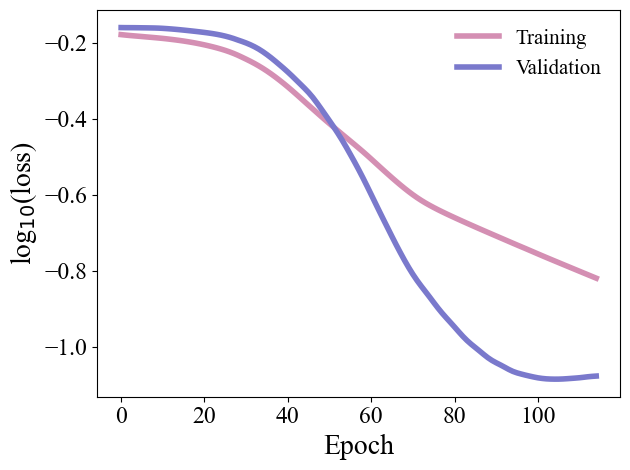

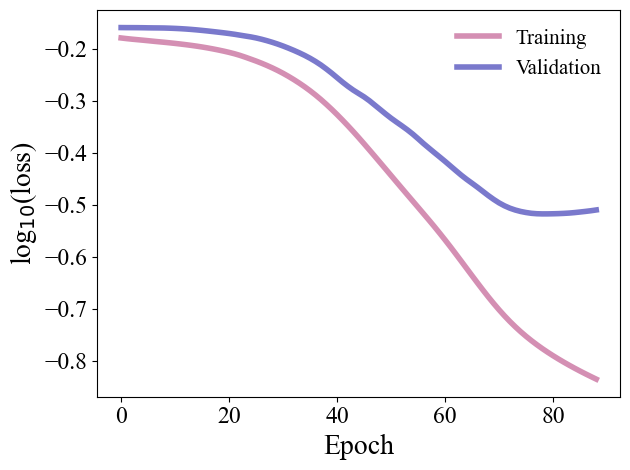

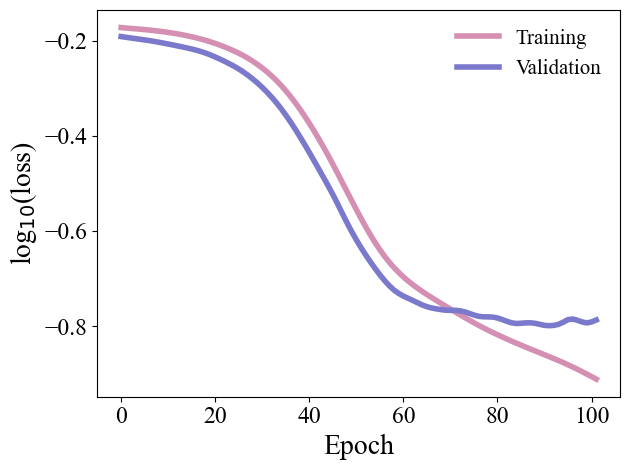

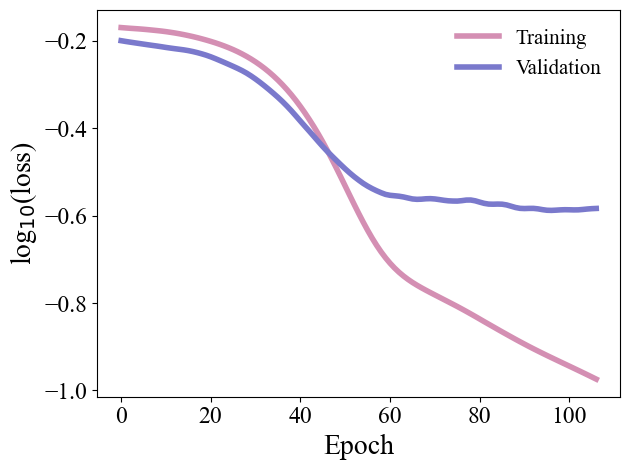

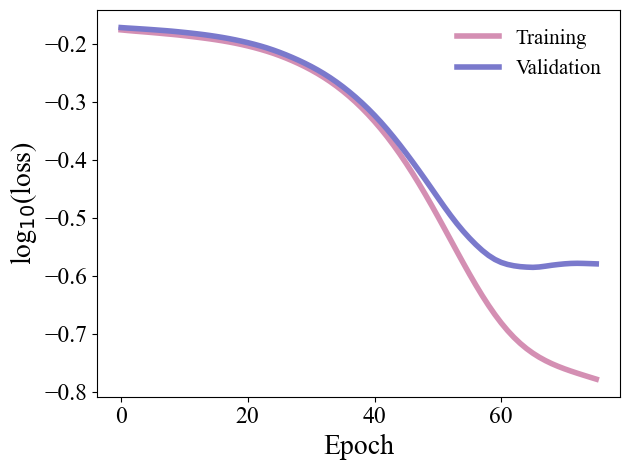

In [17]:
for i in range(5):
    loss_path = f'5fold-results/new_seed/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss_outputs_seed434.csv'

    loss = pd.read_csv(f'handpicked-kfold-results/augmented_dataset_results/{loss_path}',
                    skiprows=1, names=['epoch','loss','loss_val'])

    plt.figure()
    plt.plot(loss['epoch'], np.log10(loss['loss']), label='Training', color='#D48FB3', linewidth=4)
    plt.plot(loss['epoch'], np.log10(loss['loss_val']), label='Validation', color='#7A79CC', linewidth=4)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('log$_{10}$(loss)', fontsize=20, )

    plt.tick_params(left=True, bottom=True, axis='both', labelsize=17)

    plt.legend(frameon=False, fontsize=15)
    plt.tight_layout()
    # plt.savefig(f'handpicked-kfold-results/augmented_dataset_results/{save_path}', dpi=300)

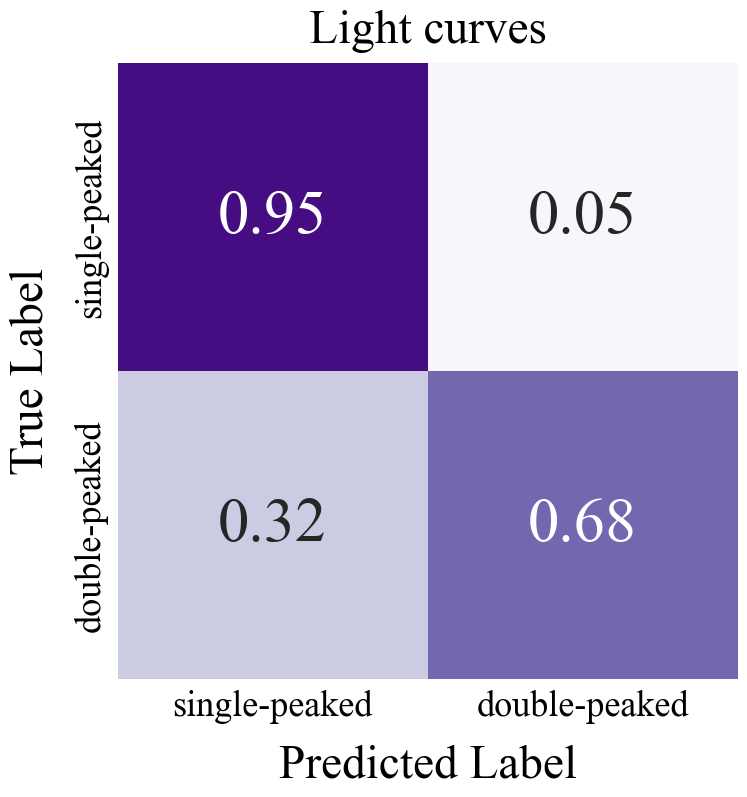

In [18]:
df = preds_df

# Calculate the confusion matrix and normalize it
cm = confusion_matrix(df["true_label"], df["prediction"])
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Create the plot
plt.figure(figsize=(8, 8))
ax = sns.heatmap(
    cm_normalized,
    annot=True,
    annot_kws={"size": 45},
    fmt=".2f",
    cmap="Purples",
    xticklabels=[class_names[label][0] for label in sorted(class_names)],
    yticklabels=[class_names[label][0] for label in sorted(class_names)],
    vmin=0,
    vmax=1,
    cbar=False,
    # cbar_kws={"pad": 0.01},
)
ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

plt.title('Light curves', fontsize=34, pad=15)
plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
plt.ylabel("True Label", fontsize=34 ,labelpad=15)

# plt.savefig(savepath, dpi=300, bbox_inches='tight')
plt.show()

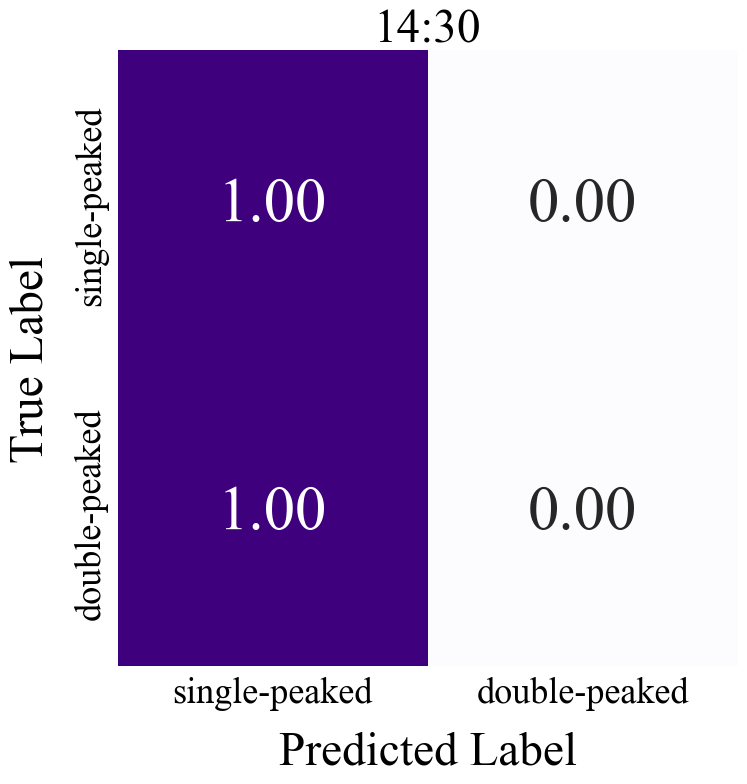

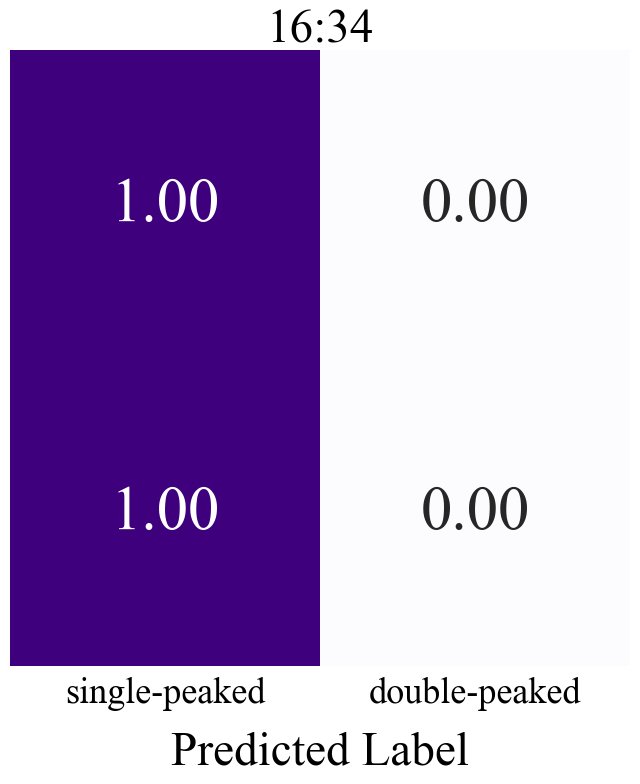

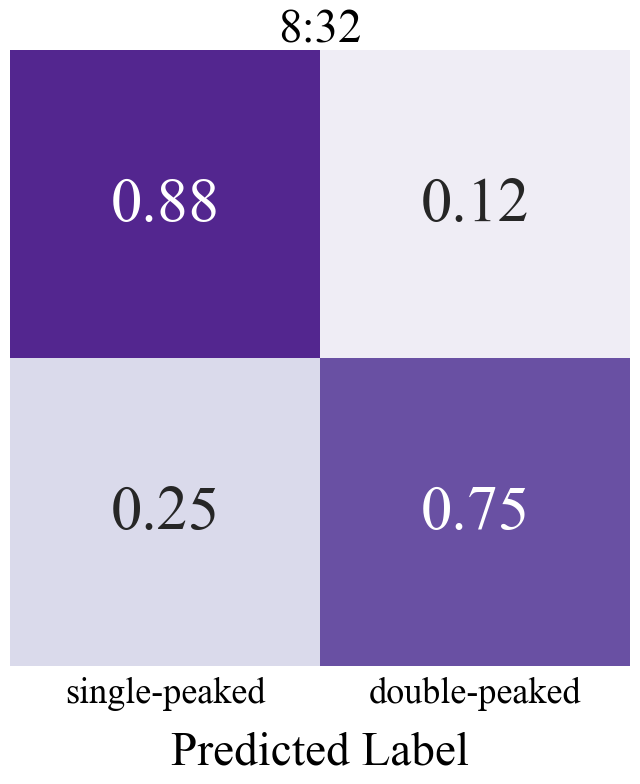

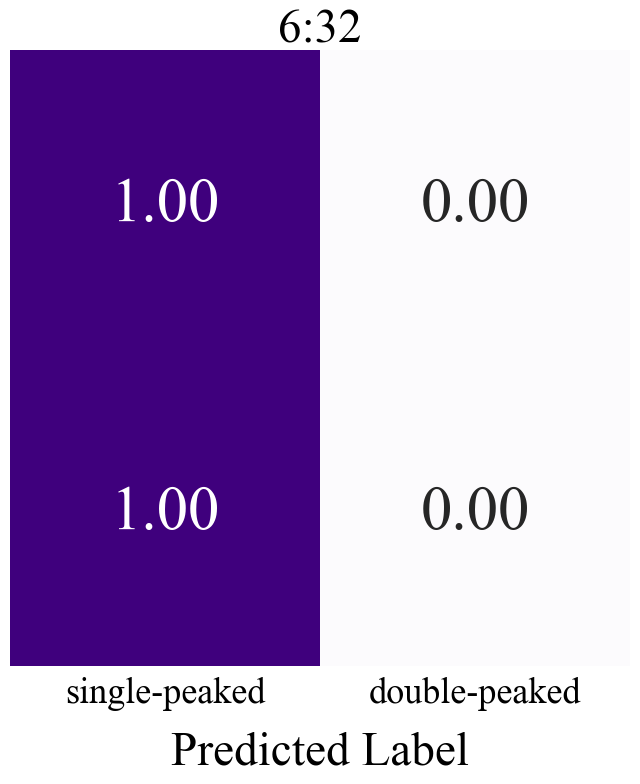

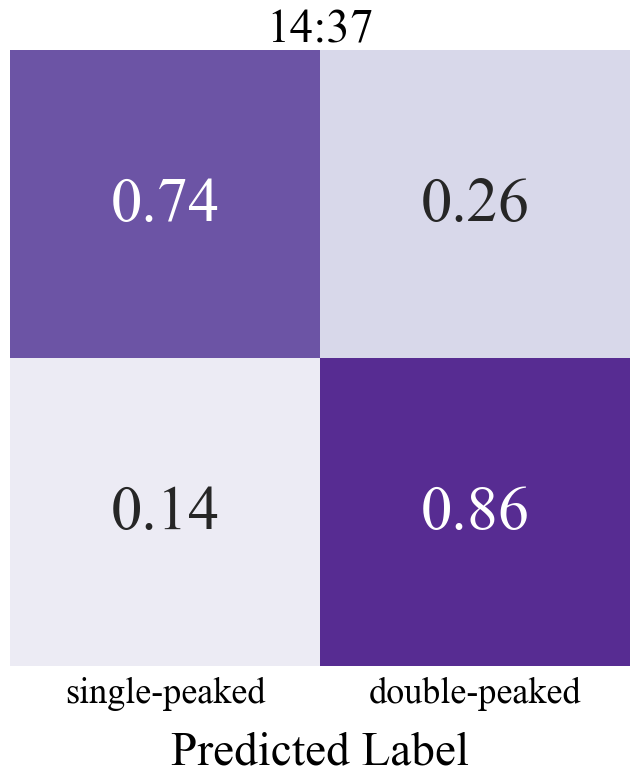

In [19]:
%matplotlib inline

df_full = preds_df
display_ratio=True

for i,fold in enumerate([kfold1,kfold2,kfold3,kfold4,kfold5]):
    df = df_full.loc[lc&fold]

    # Calculate the confusion matrix and normalize it
    cm = confusion_matrix(df["true_label"], df["prediction"])
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # Create the plot
    plt.figure(figsize=(8, 8))
    if i==0:
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=[class_names[label][0] for label in sorted(class_names)],
            yticklabels=[class_names[label][0] for label in sorted(class_names)],
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )
    else:
        ax = sns.heatmap(
            cm_normalized,
            annot=True,
            annot_kws={"size": 45},
            fmt=".2f",
            cmap="Purples",
            xticklabels=[class_names[label][0] for label in sorted(class_names)],
            yticklabels=False,
            vmin=0,
            vmax=1,
            cbar=False,
            # cbar_kws={"pad": 0.01},
        )

    ax.tick_params(left=False, bottom=False, axis='both', labelsize=26)

    plt.xlabel("Predicted Label", fontsize=34, labelpad=15)
    if i==0:
        plt.ylabel("True Label", fontsize=34 ,labelpad=15)

    if display_ratio:
        num_dp = len(df.loc[df['true_label']==1])
        total = len(df)
        plt.title(f'{num_dp}:{total}', fontsize=34)
    
    #per-fold
    # plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

In [21]:
###############
# 200 fixd epoch

loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug
loading multipeak-finetune-cFrF-picked-kfolds-aug


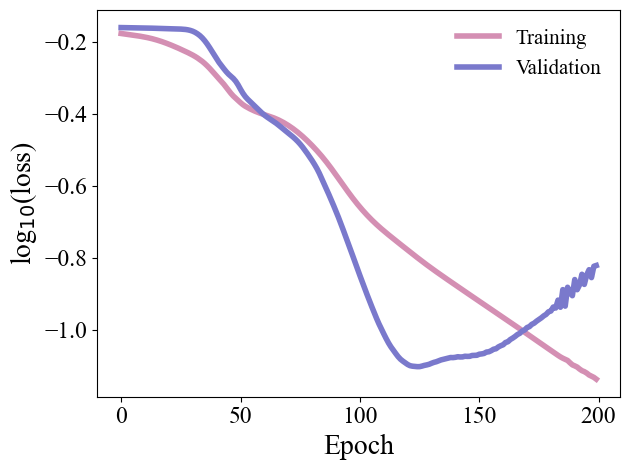

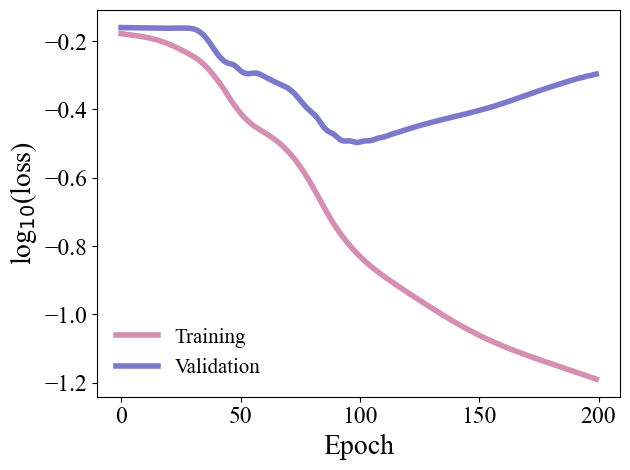

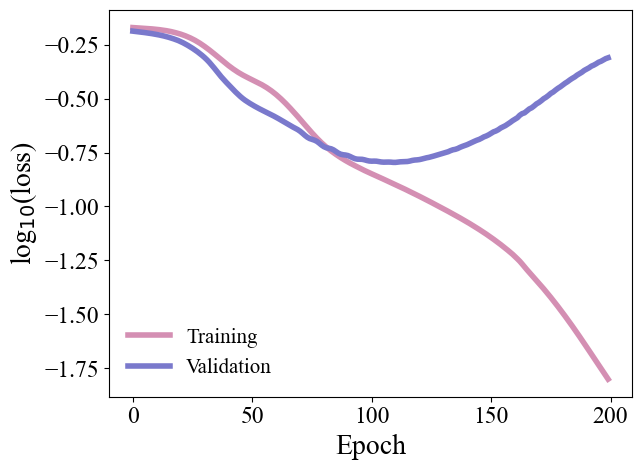

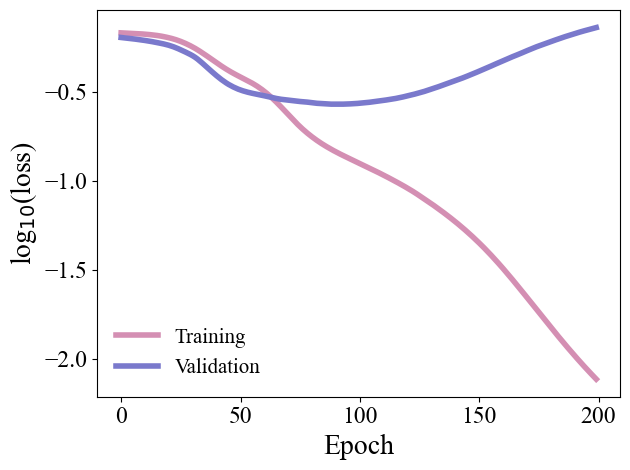

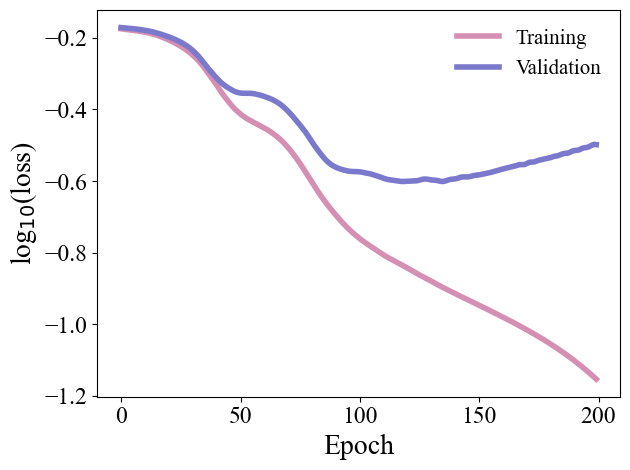

In [11]:
# post-aug (i.e. w/ GP objs)
model_label =  'multipeak-finetune-cFrF-picked-kfolds-aug'
mlp_weight = 1.0
datadir = 'all'


#read in individual object predictions from evaluate_models_single output
preds_df = pd.read_csv(f'./{model_label}+MLP+two_w{mlp_weight}_200epochs_single_objs.csv')

#read in dataset dsecription
dataset = pd.read_csv(f'./data/test/{datadir}/ZTFBTS_TransientTable.csv')

# creating placeholder column for the k-fold for which the obj belongs to the validation set for
preds_df['kfold_for_val'] = [0]*len(preds_df)

#loading in models and validation sets
directories = [
    f"models/{model_label}",
]  
names = [
    f"{model_label}",
]
models = []

paths = []
ids = []
labels = []
# Finding all checkpoints
for id, (directory, label) in enumerate(zip(directories, names)):
    paths_to_checkpoint, name, id = get_checkpoint_paths(directory, label, id)
    paths.extend(paths_to_checkpoint)
    ids.extend(id)
    labels.extend(name)

for i, path in enumerate(paths):
    print(f"loading {labels[i]}")
    # print(path)
    models.append(load_model(path))

# if obj appears in list of val_filenames from model, then update k-fold_in_valid to the model i we are on
for i in range(len(models)):
    val_filenames = models[i][-1]
    preds_df.loc[preds_df['SN'].isin(val_filenames), 'kfold_for_val'] = i

#cross-matching objects between DFs to add SN type to preds_df
types = []
for i,sn in enumerate(preds_df['SN'][::3]):
    sn_ztf = sn[:12]
    snt = dataset.loc[dataset.ZTFID==sn_ztf, 'type'].iloc[0]
    types.append([snt]*3)

preds_df['type'] = np.array(types).flatten()

preds_df.loc[preds_df['type']=='SN Ib/c', 'type'] = 'SN Ibc'



# defining dataframe-specific cuts to be used in plotting below
sp = (preds_df['true_label'] == 0)
dp = ~sp

correct = (preds_df['true_label']==preds_df['prediction'])
incorrect = ~correct

lc = (preds_df['modality']=='lightcurve')
spec = (preds_df['modality']=='spectral')
lcnspec = (preds_df['modality']=='lightcurveandspectral')

kfold1 = (preds_df['kfold_for_val']==0)
kfold2 = (preds_df['kfold_for_val']==1)
kfold3 = (preds_df['kfold_for_val']==2)
kfold4 = (preds_df['kfold_for_val']==3)
kfold5 = (preds_df['kfold_for_val']==4)

%matplotlib inline
for i in range(5):
    loss_path = f'5fold-results/200epochs/per-fold-results/{model_label}+MLP+two_lightcurve_kfold{i}_w1.0_loss_outputs.csv'

    loss = pd.read_csv(f'handpicked-kfold-results/augmented_dataset_results/{loss_path}',
                    skiprows=1, names=['epoch','loss','loss_val'])

    plt.figure()
    plt.plot(loss['epoch'], np.log10(loss['loss']), label='Training', color='#D48FB3', linewidth=4)
    plt.plot(loss['epoch'], np.log10(loss['loss_val']), label='Validation', color='#7A79CC', linewidth=4)
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('log$_{10}$(loss)', fontsize=20, )

    plt.tick_params(left=True, bottom=True, axis='both', labelsize=17)

    plt.legend(frameon=False, fontsize=15)
    plt.tight_layout()

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 135/135 [00:00<00:00, 620.44it/s]


Loading spectra ...


100%|██████████| 135/135 [00:00<00:00, 2107.67it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 30/30 [00:00<00:00, 600.82it/s]


Loading spectra ...


100%|██████████| 30/30 [00:00<00:00, 2007.23it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
Random seed: 0
thresholds: [       inf 0.7157667  0.67528296 0.66826284 0.64462066 0.527742
 0.50350195 0.500604   0.441593   0.30931643 0.25054884 0.15445681
 0.09769253 0.00130288]


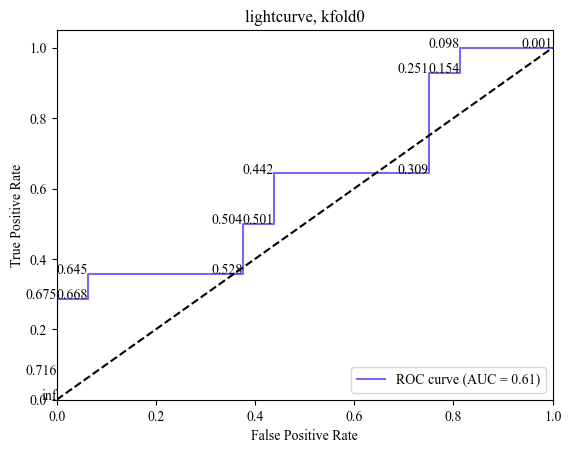

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 131/131 [00:00<00:00, 685.04it/s]


Loading spectra ...


100%|██████████| 131/131 [00:00<00:00, 2068.56it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 34/34 [00:00<00:00, 665.06it/s]


Loading spectra ...


100%|██████████| 34/34 [00:00<00:00, 2094.10it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
Random seed: 0
thresholds: [       inf 0.537144   0.40159604 0.3907979  0.38755113 0.34445027
 0.33576238 0.32836273 0.32496098 0.2691205  0.26250273 0.2620297
 0.26138556 0.25518098 0.25476515 0.2474975  0.21417    0.19599059
 0.17033976 0.1255206 ]


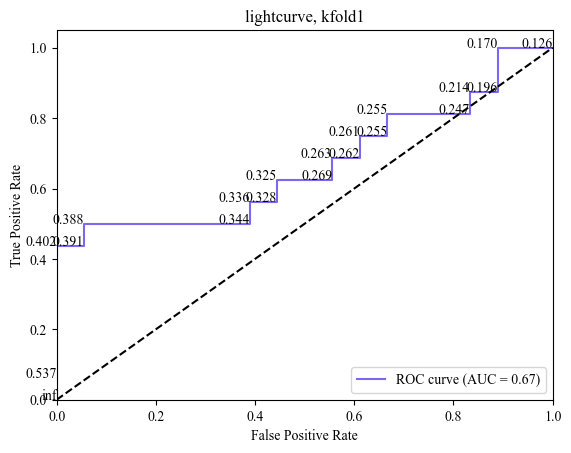

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 661.87it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2256.76it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 619.04it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 1833.30it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
Random seed: 0
thresholds: [          inf 9.8537099e-01 9.7482443e-01 9.5966506e-01 8.9651114e-01
 4.2023760e-01 3.8710529e-01 6.0719818e-02 6.0187381e-02 4.7147200e-02
 2.8287264e-04]


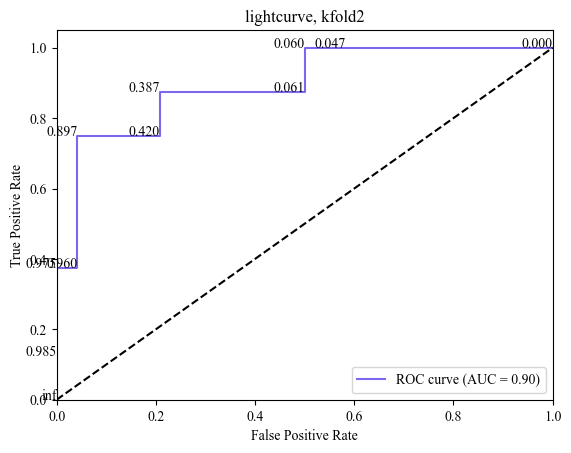

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 133/133 [00:00<00:00, 688.84it/s]


Loading spectra ...


100%|██████████| 133/133 [00:00<00:00, 2408.28it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 32/32 [00:00<00:00, 646.64it/s]


Loading spectra ...


100%|██████████| 32/32 [00:00<00:00, 1912.40it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
Random seed: 0
thresholds: [       inf 0.84614426 0.8295282  0.7351009  0.69661427 0.60932857
 0.31569597 0.27580813 0.19030833 0.167752   0.15335469 0.104883
 0.0133222 ]


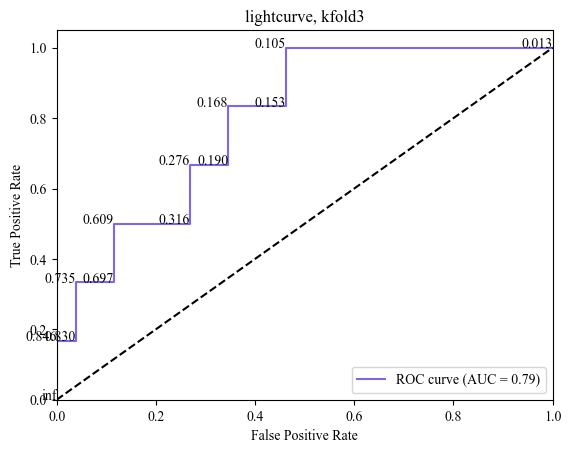

Random seed: 0
n_classes 2
Loading light curves...


100%|██████████| 128/128 [00:00<00:00, 693.65it/s]


Loading spectra ...


100%|██████████| 128/128 [00:00<00:00, 2172.59it/s]


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Loading light curves...


100%|██████████| 37/37 [00:00<00:00, 657.21it/s]


Loading spectra ...


100%|██████████| 37/37 [00:00<00:00, 2106.00it/s]
/Users/pnr5sh/Documents/phd/maven/mavendev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Finished loading spectra...
Loading redshifts...
Finished loading redshift
Loading multipeaked-ness...
Finished loading multipeaked-ness
Using hand-picked kfold splits...
Model: multipeak-finetune-cFrF-picked-kfolds-aug
Using data modalities: ['lightcurve', 'spectral']
Random seed: 0
thresholds: [       inf 0.97202736 0.96590483 0.9651019  0.941506   0.9368165
 0.9257071  0.9148724  0.84714377 0.74164283 0.45007133 0.44056088
 0.20118979 0.14164813 0.07336094 0.04702754 0.04702751 0.01658015]


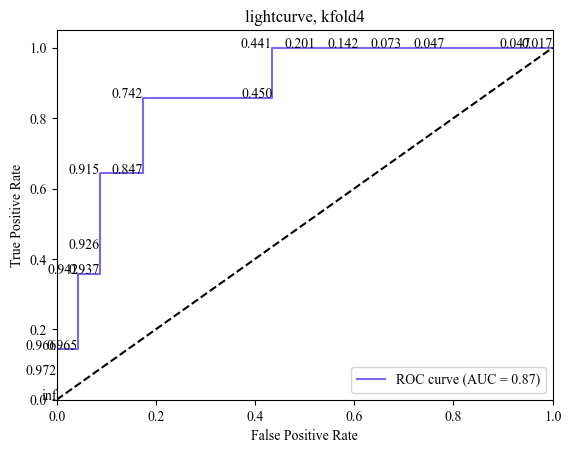

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
data_dir = f'data/test/{datadir}'
spectra_dir = f'data/test/{datadir}_spectra'
from src.utils import PyTorchMLP

kval=0
best_loss_epochs = [124, 99, 110, 89, 118]
for output, label, id in zip(models, labels, ids):
    (
        model,
        combinations,
        regression,
        classification,
        n_classes,
        cfg,
        cfg_extra_args,
        train_filenames,
        val_filenames,
    ) = output

    set_seed(cfg["seed"])

    print('n_classes', n_classes)

    # Spectral data is cut to this length
    dataset_train, nband, filenames_read, _ = load_data(
        data_dir,
        spectra_dir,
        max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
        combinations=cfg_extra_args["combinations"],
        spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
        filenames=train_filenames,
        n_classes=n_classes,
        handpicked_folds=cfg_extra_args["handpicked_folds"],
        handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
    )

    # Check that the filenames read are a subset of the training filenames from the already trained models
    assert is_subset(filenames_read, train_filenames)

    dataset_val, nband, filenames_read, _ = load_data(
        data_dir,
        spectra_dir,
        max_data_len_spec=cfg_extra_args["max_spectral_data_len"],
        combinations=cfg_extra_args["combinations"],
        spectral_rescalefactor=cfg_extra_args["spectral_rescalefactor"],
        filenames=val_filenames,
        n_classes=n_classes,
        handpicked_folds=cfg_extra_args["handpicked_folds"],
        handpicked_folds_dictpath=cfg_extra_args["handpicked_folds_dictpath"],
    )
    
    # Check that the filenames read are a subset of the training filenames from the already trained models
    assert is_subset(filenames_read, val_filenames)

    train_loader_no_aug = NoisyDataLoader(
        dataset_train,
        batch_size=cfg["batchsize"],
        noise_level_img=0,
        noise_level_mag=0,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        combinations=cfg_extra_args["combinations"],
    )

    val_loader_no_aug = NoisyDataLoader(
        dataset_val,
        batch_size=cfg["batchsize"],
        noise_level_img=0,
        noise_level_mag=0,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        combinations=cfg_extra_args["combinations"],
    )

    model = model.to(device)
    model.eval()
    
    #y_pred empty if regression is not True
    y_true, y_true_label, y_pred, lc_data = process_data_loader(
        val_loader_no_aug,
        regression,
        classification,
        device,
        model,
        combinations=cfg_extra_args["combinations"],
    )
    y_true_train, y_true_train_label, _, _ = process_data_loader(
        train_loader_no_aug,
        regression,
        classification,
        device,
        model,
        combinations=cfg_extra_args["combinations"],
    )

    print("===============================")
    print(f"Model: {label}")
    print(f"Using data modalities: {cfg_extra_args['combinations']}")
    
    embs_list, combs = get_embs(
            model, val_loader_no_aug, cfg_extra_args["combinations"], ret_combs=True
        )
    embs_list_train = get_embs(model, train_loader_no_aug, combinations)
    subclasses = torch.tensor(
        [0,1] 
    )
    embs_list, y_true_label, lc_data = filter_classes(
        embs_list, y_true_label, lc_data, subclasses
    )
    embs_list_train, y_true_train_label, _ = filter_classes(
        embs_list_train, y_true_train_label, None, subclasses
    )

    X_val, Y_val = embs_list[0], y_true_label,

    # Ensure Y is 2D (necessary for sklearn)
    if (Y_val is not None) and (len(Y_val.shape) == 1):
        Y_val = Y_val[:, np.newaxis]

    #making ROC and AUC plots

    # model = pickle.load(open(f'models/mlp-states/{model_label}+MLP+two_lightcurve_kfold{kval}_w1.0_epoch{best_loss_epochs[kval]}.pt', 'rb'))
    model = PyTorchMLP(input_dim=X_val.shape[1], seed=cfg['seed'])
    model.load_state_dict(torch.load(f'models/mlp-states/5fold-longrun/{model_label}+MLP+two_lightcurve_kfold{kval}_w1.0_epoch{best_loss_epochs[kval]}.pt')) #NOTE: fixed epoch version
    model.eval()
    
    # If validation data is provided, make predictions on that, otherwise on training data
    if X_val is not None and Y_val is not None:
        logits = model(X_val)
        probs = torch.sigmoid(logits)        # Apply sigmoid to get probabilities
        fpr, tpr, thresholds = roc_curve(Y_val.detach().numpy(), probs.detach().numpy())  # Calculate ROC
        print(f'thresholds: {thresholds}')
        roc_auc = auc(fpr, tpr)                         # Calculate AUC
        predictions = (probs >= 0.5).float() # Convert probabilities to binary predictions (threshold = 0.5)
        
        # Plot the ROC curve
        plt.figure()  
        plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc, color='mediumslateblue')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{combs[0]}, kfold{kval}')
        plt.legend(loc='lower right')
        
        for i,t in enumerate(thresholds):
            plt.text(fpr[i], tpr[i], "%.3f"%t, ha="right")

        # plt.savefig(f'figures/{model_label}_kfold{kval}_seed434_roc.png', dpi=300)
        plt.show()

    kval+=1